<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Денис! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Модель классификатора для предсказания возрастной категории пользователей на основе Web-логов для рекламной сети Йети

- Автор: Федоров Алексей Анатольевич
- Дата: 12.07.2026

<a id='цели-и-задачи-проекта'></a>
## Цели и задачи проекта
Компания Йети использует свои онлайн сервисы, Web-сайты для показа рекламы, которая оптимизируется используя демографический таргетинг, чтобы реклама достигала оптимальной целевой аудитории. Для этого компания анализирует логи посещений онлайн ресурсов пользователями. Например: категории посещаемых сайтов, частота посещения, время. И один из важных параметров для определения целевой аудитории — возраст пользователя.

1. **Тип задачи** — многоклассовая классификация, обучение с учителем (на размеченных данных).


2. **Задача** — Построение на основе логов активности пользователей, взятых с онлайн-ресурсов компании Йети, классификатора, прогнозирующего возрастную категорию пользователя.


3. **Цель** — попадание в оптимальную целевую аудиторию при показе рекламы. Возрастная категория — один из параметров для определения целевой аудитории.


4. **Целевая переменная** — `age_category`:
    - 0 — младше 18;
    - 1 — 18–25 лет;
    - 2 — 26–40 лет;
    - 3 — 41–55 лет;
    - 4 — 56+ лет.


5. **Метрики качества модели**
    - **Основная** — F1:      
      $$F1 = \frac{2 \cdot \mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}$$ — гармоническое среднее.
    - **Вспомогательные** — Precision и Recall.
    - **Тип усреднения** — одинаковая оценка по всем классам TARGET, поэтому **макро-усреднение**.
    
    
6. **Требования к модели**
    - F1 не ниже 0.75;
    - оптимизация точности или охвата не требуется.


<a id='описание-данных'></a>
## Описание данных
### Таблица users
- **user_id** — уникальный идентификатор пользователя.
- **age_category** — возрастная категория пользователя, которую модель должна предсказать. Содержит следующие значения:
  - `0` — младше 18;
  - `1` — 18–25 лет;
  - `2` — 26–40 лет;
  - `3` — 41–55 лет;
  - `4` — 56+ лет.

### Таблица visits
- **date** — дата посещения сайта.
- **daytime** — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
- **session_id** — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- **user_id** — уникальный идентификатор пользователя.
- **website_category** — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

### Таблица ads_activity
- **date** — дата посещения сайта.
- **daytime** — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
- **session_id** — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- **user_id** — уникальный идентификатор пользователя.
- **website_category** — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

### Таблица surf_depth
- **user_id** — уникальный идентификатор пользователя.
- **surf_depth** — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории: поверхностно, средне, глубоко.

### Таблица primary_device
- **user_id** — уникальный идентификатор пользователя.
- **primary_device** — информация о типе основного устройства пользователя для выхода в Интернет.

### Таблица cloud_usage
- **user_id** — уникальный идентификатор пользователя.
- **cloud_usage** — `True` означает, что пользователь обращается к [облачным](https://practicum.yandex.ru/blog/oblachnye-tehnologii/) ресурсам типа [Яндекс 360](https://360.yandex.ru/) прямо или через посещаемые сайты.

## Подготовка среды и библиотек

👉 После выполнения скрипта conda (через ячейку ниже) по добавлению вирт. окрудения и ядра Jupyter, надо:
- дождаться завершения выполнения скрипта в ячейке 2 (видно по звёздочке слева вверху);
- проверить его лог и убедиться, что скрипт выполнился (warning - нормально);
- **перегрузить страницу (Ctrl+F5);
- выбрать ядро review_env** вручную, через меню Kernal (внизу меню); 
- рестартовать ядро. 

Тетрадь настроена на работу в изоляции со своим ядром с **Python 3.11 внутри**.

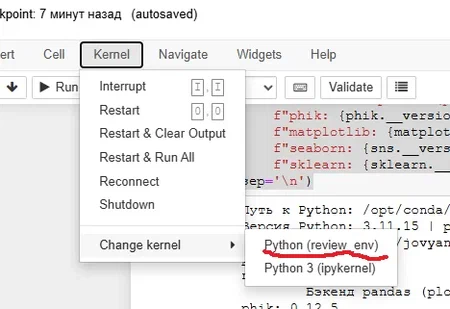

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Код должен полностью воспроизводился в JupyterHub Практикума, без дополнительных манипуляций.\
Представь, что ты пишешь Python приложение, не умеющее переключать ядра.</font>
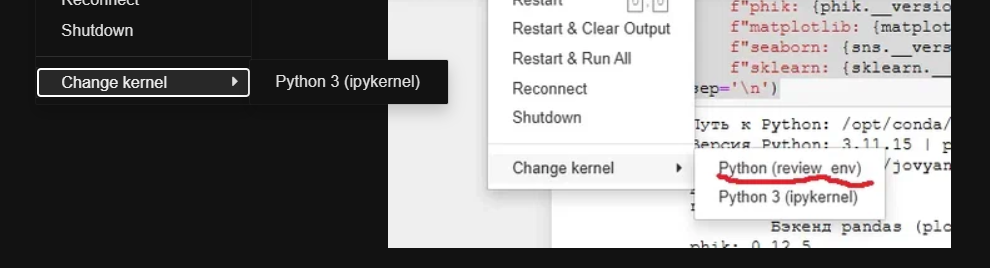

<span style="color: purple; font-weight: bold">Комментарий студента it.1</span>

Добрый день, Павел! Рад вас видеть!

Я Алексей.
Мы вроде с прошлым проектом так же с вами работали.

Проблема в том, что это venv+kernel - **единственно правильный и рабочий вариант** сдачи проектов, к которому я пришёл спустя время. 
**Работа делается исключительно в Яедекс Jupyter Hub, а не локально**. Если на виртуалках студентов переключение ядер разрешено, а **на виртуалках ревьюверов - нет**, то это проблема. Её надо обсудить с авторами курса. Что-то не верится в это. Вероятно:
 - вы вполнили ячейку Conda с установкой зависимостей;
 - не перегрузили Jupyter через Ctrl + F5, либо Restart в Hub'е, поэтому, ядро не появляется.
 
**У студентов смена ядер в Jupyter Hub Yandex разрешена. Проверьте, пожалуйста: у вас тоже должна быть разрешена, иначе это тупиковый вариант - DLL Hell, либо нужно публиковать в каждом проекте единый список зависимостей.**

Если действительно запрещена смена ядер, то пришлите мне, пожалуйста ваш список зависимостей, я его поставлю у себя в ячейке через pip (по старинке), отдебажу и адаптирую всю работу. Она сразу не взлетит. Python будет 3.9. Какие у вас в site-packages зависимости - я знать не могу.

Как вы можете помнить, в прошлый раз была другая проблема: случайные работы студентов формируют помойку в site-packages дефолтного Kernel ревьювера Python 3. Платформа Питона, его runtime, не имеют механизма **Strong Name и GAC, как Microsoft .Net**. Поэтому, здесь возникает **DLL Hell**. Чтобы его избежать - два варианта:
 - использовать venv + kernel (изоляцию) - это и есть стандартный единственно правильный подход;
 - вычистить у вас глобальный site-packages и дать ему залиться теми модулями, которые у меня будут ставится в ячейке Jupyter через pip или Conda в дефолтное ядро Python 3.
 
И третий стремноватый путь, который я описал в начале.
 
**Здесь чудес нет. Всё просто, как 2 + 2.**
 
Если я сейчас загружу СВОИ зависимости, как это прокатывало во многих работах ранее (через pip в ячейке в глобальный site-packages), то они встанут на ваше ядро "Python 3" 50% на 50% (казино). Может быть конфликт версий, DLL Hell. И это гиблый путь. Мы будем эксперементировать с версиями долго, если что-то не встанет.

Это происходит потому, что у pandas, numpy и sikit-learn много транзитивных зависимостей, указанных границами версий (не точная версия, а интервал).
 
Кроме того, я в этот раз, применив ядро, взял свежий **Python 3.11**. Его в дефолтном ядре обновить так просто не получится. И я теперь ограничен этой версией. У меня и остальной код немного поднят в версиях и протестирован с Python 3.11, а не 3.9, как на виртуалках. Поставить всё это в изолированный venv - стандартная практика.

Прописал в этот ipynb в метаданные ядро review_env. После выполнения ячейки с Conda скриптом и Ctrl+F5 должно подцепиться автоматом.

### Зависимости

In [1]:
# имя нашего виртуального окружения и ядра Jupyter
ENV_NAME="review_env"
# версия runtime Питона, которую будем использовать
PYTHON_VERSION="3.11"

%env ENV_NAME=review_env
%env PYTHON_VERSION=3.11

env: ENV_NAME=review_env
env: PYTHON_VERSION=3.11


In [2]:
%%writefile requirements.txt
# ── базовые зависимости для EDA и ML ──────────────────────────────
numba==0.58.1          # нужен для scikit-learn 1.6.1 и pandas
pyarrow==14.0.1        # поддержка типа данных string в pandas
numpy==1.25.2
pandas==2.1.4
jinja2>=3.1.2
phik==0.12.5
seaborn==0.13.2
statsmodels==0.14.1
matplotlib==3.9.2
scikit-learn==1.6.1
tqdm==4.66.1
ipywidgets==8.1.2 
ipykernel
joblib
dill==0.4.1

Overwriting requirements.txt


In [3]:
%%bash
set -euo pipefail

# 1. Создаём изолированное окружение (если его ещё нет)
if ! conda env list | grep -qw "${ENV_NAME}"; then
    conda create -y -n "${ENV_NAME}" python="${PYTHON_VERSION}"
fi

# 2. Обновляем pip и ставим зависимости строго из requirements.txt
conda run -n "${ENV_NAME}" python -m pip install --upgrade pip
conda run -n "${ENV_NAME}" python -m pip install -q -r requirements.txt

# 3. Регистрируемb kernel в домашней директории пользователя (--user)
conda run -n "${ENV_NAME}" python -m ipykernel install --user \
    --name "${ENV_NAME}" \
    --display-name "Python (${ENV_NAME})"

echo "✅ Окружение '${ENV_NAME}' готово. Выберите kernel 'Python (${ENV_NAME})' в Jupyter."


Installed kernelspec review_env in /home/jovyan/.local/share/jupyter/kernels/review_env

✅ Окружение 'review_env' готово. Выберите kernel 'Python (review_env)' в Jupyter.


In [4]:
import subprocess

proc = subprocess.run(
    ["jupyter", "kernelspec", "list"],
    capture_output=True,
    text=True,
    check=True,
)
has_review_env = ENV_NAME in proc.stdout

status_label = f'✅ Ядро {ENV_NAME} установлено' if has_review_env else '❌ Ядро {ENV_NAME} не установлено'
print(status_label)

✅ Ядро review_env установлено


👉 После использования, проверки работы, можно удалить ядро и env  выполнив ячейку ниже.

In [5]:
"""
%%bash
set -euo pipefail

echo "⚠️  Убедитесь, что ноутбук работает НЕ на ядре review_env (переключитесь на python3)!"

# 1. Удаляем kernelspec (если существует)
jupyter kernelspec uninstall -y "${ENV_NAME}" 2>/dev/null || echo "kernel ${ENV_NAME} уже отсутствует"

# 2. Удаляем Conda-окружение (если существует)
conda env remove -y -n "${ENV_NAME}" 2>/dev/null || echo "env ${ENV_NAME} уже отсутствует"

echo "✅ Очистка завершена."

# 3. Показываем, что осталось
echo "── Ядра ──"
jupyter kernelspec list
echo "── Окружения ──"
conda env list
""";

### Импорты и версии библиотек

In [6]:
import contextlib
import gc
import os
import sys
import time
import warnings
import inspect
import dill
from pprint import pprint
from datetime import datetime
from dataclasses import dataclass
from functools import reduce
from operator import mul
from itertools import combinations
from typing import Protocol, Callable

import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from IPython.display import HTML, Markdown, display_html
from joblib import Memory
from matplotlib.ticker import PercentFormatter
from phik import phik_matrix
import sklearn
from sklearn.inspection import permutation_importance
from sklearn import config_context
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.feature_selection import (
    RFECV, 
    SequentialFeatureSelector, 
    VarianceThreshold, 
    mutual_info_classif, 
    SelectFromModel
)
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge, SGDRegressor
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,    
    make_scorer,    
    precision_score,    
    recall_score,        
    brier_score_loss,
    ConfusionMatrixDisplay,
)
from sklearn.frozen import FrozenEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    StratifiedKFold,
    cross_validate,
    train_test_split,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, MinMaxScaler, OneHotEncoder, SplineTransformer,
    StandardScaler, TargetEncoder, RobustScaler)
from sklearn.svm import LinearSVC, SVC
from sklearn.utils.validation import check_is_fitted
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from tqdm.auto import tqdm

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

In [7]:
print(
    f"Путь к Python: {sys.executable}",
    f"Версия Python: {sys.version}",
    f"Текущий путь: {os.getcwd()}",
    f"pandas: {pd.__version__}",
    f"numpy: {np.__version__}"
    f"\n\tБэкенд pandas (plotting): {pd.options.plotting.backend}",
    f"phik: {phik.__version__}",
    f"matplotlib: {matplotlib.__version__}",
    f"seaborn: {sns.__version__}",
    f"sklearn: {sklearn.__version__}",
sep='\n')

Путь к Python: /opt/conda/envs/review_env/bin/python
Версия Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:34:02) [GCC 14.3.0]
Текущий путь: /home/jovyan/work
pandas: 2.1.4
numpy: 1.25.2
	Бэкенд pandas (plotting): matplotlib
phik: 0.12.5
matplotlib: 3.9.2
seaborn: 0.13.2
sklearn: 1.6.1


### Проверка виртуальных окружений (нужно review_env)

Раскомментить, если проблемы с выбором ядра.

In [8]:
"""
%%bash
conda env list

# Установлен ли sklearn стоит в env, а не в системе
conda run -n review_env python -c "import sys, sklearn; print(sys.executable, sklearn.__version__)"

# Ядра, которые видит Jupyter
jupyter kernelspec list
""";

<a id='общие-функции'></a>
### Общие функции

<a id='базовые'></a>
#### Базовые

In [9]:
def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = (
        set(ints) if ints is not None
        else set(data_frame.select_dtypes(include="integer").columns)
    )
        
    floats_actual = (
        set(floats) if floats is not None
        else set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual    
    
    cats_actual = (
        set(cats) if cats is not None
        else set(data_frame.select_dtypes(include=["object", "string"]).columns)
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame

<a id='базовый-eda'></a>
#### Базовый EDA

In [10]:
def normalize_text_cols(df, col_names, to_lower=True):
    """
        Конвертирует колонки col_names в string, обрезает пробелы с концов и нормализует пробелы внутри строк.
        Если задано to_lower, то приводит к нижнему регистру.
    """
    for name in col_names:        
        df[name] = df[name].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
        if to_lower:
            df[name] = df[name].str.lower()
            
def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def get_quasi_consts_numeric(df, names, threshold=0.1):
    vs_quasi = VarianceThreshold(threshold=threshold)     
    numerical_data = df[list(names)]
    vs_quasi.fit(numerical_data)
    return [col for col, keep in zip(names, vs_quasi.get_support()) if not keep]

def get_quasi_consts_categories(df, names):
    return [col for col in list(names)
                      if df[col].value_counts(normalize=True).iloc[0] > 0.90]

def drop_columns_inplace_safe(df, cols):
    existing_cols = df.columns.intersection(cols)
    df.drop(columns=existing_cols, inplace=True)                        

#### Статистический анализ

In [11]:
def check_vif(df, fields, top=10):
    """Расчет фактора инфляции дисперсии (VIF) для проверки мультиколлинеарности.

    Интерпретация значений VIF:
    - VIF = 1: коллинеарность отсутствует.
    - 1 < VIF <= 5: умеренная коллинеарность (допустимо).
    - VIF > 10: критический уровень, признак рекомендуется удалить.

    Важно: функция удаляет строки с пропусками (dropna).
    """
    df_vif = df[list(fields)].astype(float).dropna()

    df_with_const = add_constant(df_vif)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_vif.columns

    vif_data["VIF"] = [
        variance_inflation_factor(
            df_with_const.values, df_with_const.columns.get_loc(col)
        )
        for col in df_vif.columns
    ]

    return vif_data.sort_values(by="VIF", ascending=False).head(top)

def print_high_corr_spearman_pairs(corr, threshold=0.7):
    print("\nСИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Spearman |rho| > 0.7):")
    print("-" * 60)

    pairs = corr.unstack().reset_index()
    pairs.columns = ["Feature 1", "Feature 2", "Spearman"]

    pairs = pairs[pairs["Feature 1"] < pairs["Feature 2"]]

    high_corr_pairs = pairs[pairs["Spearman"].abs() > threshold].sort_values(
        by="Spearman",
        key=lambda s: s.abs(),
        ascending=False
    )

    if not high_corr_pairs.empty:
        for _, row in high_corr_pairs.iterrows():
            print(f"{row['Feature 1']:20} <---> {row['Feature 2']:20} | Spearman: {row['Spearman']:.4f}")
    else:
        print(f"✅ Сильно скоррелированных пар с |Spearman| > {threshold} не обнаружено.")

    print("-" * 60)

    return high_corr_pairs

#### Обучение

In [12]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Совместимый с новыми joblib патч через print_progress."""
    original_print_progress = joblib.parallel.Parallel.print_progress

    def patched_print_progress(self):
        # n_completed_tasks обновляется joblib'ом
        tqdm_object.n = self.n_completed_tasks
        tqdm_object.refresh()
        return original_print_progress(self)

    joblib.parallel.Parallel.print_progress = patched_print_progress
    try:
        yield tqdm_object
    finally:
        joblib.parallel.Parallel.print_progress = original_print_progress
        tqdm_object.close()
        
def sigmoid(x):
    return 1 / (1  + np.exp(-x))

##### Настройки библиотек

In [13]:
memory = Memory(location='./cache_pipeline', verbose=0)
sns.set_theme(style="whitegrid") # светлосерая сетка

In [14]:
LOCAL_DATA_PATH = '/datasets/'
S3_DATA_PATH = 'https://code.s3.yandex.net/datasets/'
SEED = 42
TARGET = 'age_category'

class YetiDatasetFilesProto(Protocol):
    users: str
    visits: str
    ads: str
    surf: str
    device: str
    cloud: str

@dataclass(frozen = True)
class YetiDatasetFiles:
    users: str = 'ds_s13_users.csv'
    visits: str = 'ds_s13_visits.csv'
    ads: str = 'ads_activity.csv'
    surf: str = 'surf_depth.csv'
    device: str = 'primary_device.csv'
    cloud: str = 'cloud_usage.csv'

## Загрузка данных, ознокомление и начальная обработка

#### Общий код

In [15]:
def load_df(file_name):
    local_path = LOCAL_DATA_PATH + file_name
    s3_path = S3_DATA_PATH + file_name
    
    data_path = local_path if os.path.exists(local_path) else s3_path
    df = pd.read_csv(data_path, decimal='.', sep=',', skipinitialspace=True)
    df_shape = df.shape
    print(f'✅ Датасет загружен с "{data_path}" содержит: {df_shape[0]} строк')    
    
    return df

In [16]:
def pre_analyze_ds(df):    
    display(df.dtypes.to_frame(name='type'))
    display(df.head())
    print('Уникальность ключа:', df['user_id'].is_unique)
    print('Явные полные дубликаты:', df.duplicated().sum())
    display(df.isna().sum().to_frame(name='missing_count'))
    
def dedup_full_rows(df):        
    prev = df.shape[0]
    df.drop_duplicates(inplace=True)
    if isinstance(df.index, pd.RangeIndex):
        df.reset_index(drop=True, inplace=True)
    count = df.shape[0]
    print(f'✅ Датасет {df.attrs["name"]} очищен от дубликатов: {prev} --> ' \
        f'{count} / удалено: {prev - count} ')

#### Users

In [17]:
df_users = load_df(YetiDatasetFiles.users)
df_users.attrs['name'] = YetiDatasetFiles.users

✅ Датасет загружен с "/datasets/ds_s13_users.csv" содержит: 5913 строк


In [18]:
normalize_text_cols(df_users, df_users.select_dtypes(include=['object']).columns)

✅ Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [19]:
pre_analyze_ds(df_users)

,type
user_id,string[python]
age_category,int64


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


Уникальность ключа: False
Явные полные дубликаты: 87


,missing_count
user_id,0
age_category,0


In [20]:
downcast_columns_for_ml(df_users, ints=(), cats=(TARGET,), floats=());
age_labels = {
    0: '0: <18 лет',
    1: '1: 18-25 лет',
    2: '2: 26-40 лет',
    3: '3: 41-55 лет',
    4: '4: 56+ лет'
}

df_users[TARGET] = df_users[TARGET].cat.rename_categories(age_labels)

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [21]:
users_count = dedup_full_rows(df_users)

✅ Датасет ds_s13_users.csv очищен от дубликатов: 5913 --> 5826 / удалено: 87 


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

👉 Добавить в pre_pipeline удаление дубликатов.

In [22]:
print('Уникальность ключа:', df_users['user_id'].is_unique)

Уникальность ключа: True


In [23]:
get_reference_info(df_users, TARGET)

**age_category:** `['0: <18 лет', '1: 18-25 лет', '2: 26-40 лет', '3: 41-55 лет', '4: 56+ лет']` = **5**



,count,%
age_category,,
4: 56+ лет,1766,30.31
2: 26-40 лет,1439,24.70
3: 41-55 лет,1254,21.52
0: <18 лет,853,14.64
1: 18-25 лет,514,8.82



Пропущено: 0




In [24]:
display(df_users.dtypes)
display(df_users.index.dtype)

user_id         string[python]
age_category          category
dtype: object

dtype('int64')

#### Ads activity

In [25]:
df_ads = load_df(YetiDatasetFiles.ads)
df_ads.attrs['name'] = YetiDatasetFiles.ads

✅ Датасет загружен с "/datasets/ads_activity.csv" содержит: 5826 строк


In [26]:
normalize_text_cols(df_ads, df_ads.select_dtypes(include=['object']).columns)

Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [27]:
pre_analyze_ds(df_ads)

,type
user_id,string[python]
ads_activity,string[python]


,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


Уникальность ключа: False
Явные полные дубликаты: 233


,missing_count
user_id,0
ads_activity,0


In [28]:
downcast_columns_for_ml(df_ads, cats=('ads_activity',), ints=(), floats=());

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [29]:
ads_count = dedup_full_rows(df_ads)

✅ Датасет ads_activity.csv очищен от дубликатов: 5826 --> 5593 / удалено: 233 


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

👉 Добавить в pre_pipeline удаление дубликатов.

In [30]:
print('Уникальность ключа:', df_ads['user_id'].is_unique)

Уникальность ключа: True


In [31]:
get_reference_info(df_ads, 'ads_activity')

**ads_activity:** `['очень редко', 'очень часто', 'редко', 'умеренно', 'часто']` = **5**



,count,%
ads_activity,,
умеренно,1824,32.61
редко,1634,29.22
часто,1069,19.11
очень редко,841,15.04
очень часто,225,4.02



Пропущено: 0




In [32]:
display(df_ads.dtypes)
display(df_ads.index.dtype)

user_id         string[python]
ads_activity          category
dtype: object

dtype('int64')

#### Surf depth

In [33]:
df_surf = load_df(YetiDatasetFiles.surf)
df_surf.attrs['name'] = YetiDatasetFiles.surf

✅ Датасет загружен с "/datasets/surf_depth.csv" содержит: 5715 строк


In [34]:
normalize_text_cols(df_surf, df_surf.select_dtypes(include=['object']).columns)

Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [35]:
pre_analyze_ds(df_surf)

,type
user_id,string[python]
surf_depth,string[python]


,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


Уникальность ключа: True
Явные полные дубликаты: 0


,missing_count
user_id,0
surf_depth,0


In [36]:
downcast_columns_for_ml(df_surf, cats=('surf_depth',), ints=(), floats=());

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [37]:
surf_count = df_surf.shape[0]

In [38]:
get_reference_info(df_surf, 'surf_depth')

**surf_depth:** `['глубоко', 'поверхностно', 'средне']` = **3**



,count,%
surf_depth,,
средне,2435,42.61
поверхностно,2424,42.41
глубоко,856,14.98



Пропущено: 0




In [39]:
display(df_surf.dtypes)
display(df_surf.index.dtype)

user_id       string[python]
surf_depth          category
dtype: object

dtype('int64')

#### Primary device

In [40]:
df_device = load_df(YetiDatasetFiles.device)
df_device.attrs['name'] = YetiDatasetFiles.device

✅ Датасет загружен с "/datasets/primary_device.csv" содержит: 5669 строк


In [41]:
normalize_text_cols(df_device, df_device.select_dtypes(include=['object']).columns)

✅ Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [42]:
pre_analyze_ds(df_device)

,type
user_id,string[python]
primary_device,string[python]


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,пк
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,пк


Уникальность ключа: True
Явные полные дубликаты: 0


,missing_count
user_id,0
primary_device,0


In [43]:
downcast_columns_for_ml(df_device, cats=('primary_device',), ints=(), floats=());

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [44]:
device_count = df_device.shape[0]

In [45]:
get_reference_info(df_device, 'primary_device')

**primary_device:** `['ноутбук', 'пк', 'планшет', 'смартфон']` = **4**



,count,%
primary_device,,
смартфон,3083,54.38
пк,1275,22.49
ноутбук,923,16.28
планшет,388,6.84



Пропущено: 0




In [46]:
display(df_device.dtypes)
display(df_device.index.dtype)

user_id           string[python]
primary_device          category
dtype: object

dtype('int64')

#### Cloud usage

In [47]:
df_cloud = load_df(YetiDatasetFiles.cloud)
df_cloud.attrs['name'] = YetiDatasetFiles.cloud

✅ Датасет загружен с "/datasets/cloud_usage.csv" содержит: 5680 строк


In [48]:
normalize_text_cols(df_cloud, df_cloud.select_dtypes(include=['object']).columns)

✅ Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [49]:
pre_analyze_ds(df_cloud)

,type
user_id,string[python]
cloud_usage,bool


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


Уникальность ключа: True
Явные полные дубликаты: 0


,missing_count
user_id,0
cloud_usage,0


In [50]:
downcast_columns_for_ml(df_cloud, ints=('cloud_usage',), cats=(), floats=());

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [51]:
cloud_count = df_cloud.shape[0]

In [52]:
get_reference_info(df_cloud, 'cloud_usage')

**cloud_usage:** `[0, 1]` = **2**



,count,%
cloud_usage,,
1,2951,51.95
0,2729,48.05



Пропущено: 0




In [53]:
display(df_cloud.dtypes)
display(df_cloud.index.dtype)

user_id        string[python]
cloud_usage              int8
dtype: object

dtype('int64')

#### Visits

In [54]:
df_visits = load_df(YetiDatasetFiles.visits)
df_visits.attrs['name'] = YetiDatasetFiles.visits

✅ Датасет загружен с "/datasets/ds_s13_visits.csv" содержит: 1065745 строк


In [55]:
normalize_text_cols(df_visits, df_visits.select_dtypes(include=['object']).columns)

✅ Нормализовали текстовые поля и преобразовали в string.

👉 Добавить в pre_pipeline.

In [56]:
pre_analyze_ds(df_visits)

,type
date,string[python]
daytime,string[python]
session_id,string[python]
user_id,string[python]
website_category,string[python]


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,category 05


Уникальность ключа: False
Явные полные дубликаты: 15750


,missing_count
date,0
daytime,0
session_id,0
user_id,0
website_category,0


In [57]:
downcast_columns_for_ml(df_visits, cats=('daytime', 'website_category',), ints=(), floats=());
df_visits['date'] = pd.to_datetime(df_visits['date'])

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

✅ Оптимизировали типы признаков датасета.

👉 Добавить в pre_pipeline.

In [58]:
visits_count = dedup_full_rows(df_visits)

✅ Датасет ds_s13_visits.csv очищен от дубликатов: 1065745 --> 1049995 / удалено: 15750 


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

👉 Добавить в pre_pipeline удаление дубликатов.

In [59]:
get_reference_info(df_visits, 'daytime')

**daytime:** `['вечер', 'день', 'ночь', 'утро']` = **4**



,count,%
daytime,,
день,383328,36.51
вечер,376495,35.86
утро,208349,19.84
ночь,81823,7.79



Пропущено: 0




In [60]:
get_reference_info(df_visits, 'website_category')

**website_category:** `['category 01', 'category 02', 'category 03', 'category 04', 'category 05', 'category 06', 'category 07', 'category 08', 'category 09', 'category 10', 'category 11', 'category 12', 'category 13', 'category 14', 'category 15', 'category 16', 'category 17', 'category 18', 'category 19', 'category 20']` = **20**



,count,%
website_category,,
category 03,69129,6.58
category 13,67647,6.44
category 05,59720,5.69
category 06,56243,5.36
category 08,55195,5.26
category 19,54568,5.20
category 07,53906,5.13
category 09,53089,5.06
category 01,52401,4.99



Пропущено: 0




In [61]:
df_visits['date'].describe()

count                          1049995
mean     2025-11-07 11:56:51.029957376
min                2025-11-01 00:00:00
25%                2025-11-04 00:00:00
50%                2025-11-08 00:00:00
75%                2025-11-11 00:00:00
max                2025-11-14 00:00:00
Name: date, dtype: object

In [62]:
display(df_visits.dtypes)

date                datetime64[ns]
daytime                   category
session_id          string[python]
user_id             string[python]
website_category          category
dtype: object

### Промежуточный вывод
Загружены 6 датасетов users, visits, ads_activity, surf_depth, primary_device, cloud_usage и данные соотвествуют описанию, названия колонок в snake case, категориальные данные соотвествуют описанию, неявных дубликатов и пропусков после нормализации строк не выявлено. Однако, есть полные явные дубликаты: users, ads_activity, visits, которые удалены. Так же, есть расхождение числа строк, после соединения датасетов появятся пропуски. В исходных датсетах без пропусков.

- Все датасеты не содержат пропусков (`missing_count = 0`).
- После удаления полных дубликатов:
  - `users`: `5 913 → 5 826` (удалено `87`).
  - `ads_activity`: `5 826 → 5 593` (удалено `233`).
  - `visits`: `1 065 745 → 1 049 995` (удалено `15 750`).
- Остальные (`surf_depth`, `primary_device`, `cloud_usage`) дубликатов не имели.
- Во всех датасетах после дедупликации ключ `user_id` стал уникальным (кроме visits), что позволяет однозначно объединять таблицы.

**Преобразования типов**
- Нормализация текстовых полей: приведение к единому регистру и удаление лишних пробелов.
- Оптимизация типов данных: категориальные переменные переведены в `category`, числовые — в `int8` для экономии памяти.
- Удаление явных дубликатов строк.
- Для `visits` поле `date` преобразовано в `datetime`.

**Категориальные признаки**
- `users`: `age_category` — 5 возрастных групп, наиболее многочисленная — группа 4 (`30,3%`).
- `ads_activity`: 5 уровней активности, преобладает «умеренно» (`32,6%`).
- `surf_depth`: 3 уровня глубины просмотра, «средне» и «поверхностно» представлены примерно поровну (`~42,5%` каждый).
- `primary_device`: 4 типа устройств, доминирует «смартфон» (`54,4%`).
- `cloud_usage`: бинарный признак, распределён почти равномерно (`51,9%` — `True`).
- `visits`:
  - `daytime` — 4 временных интервала, наибольшая активность днём и вечером (`~36%` каждый).
  - `website_category` — 20 категорий сайтов, распределение относительно равномерное (`3,7%`–`6,6%`).
  - `date` — период с `2025-11-01` по `2025-11-14` (14 дней).
  
Данные готовы к анализу. visits содержит много записей для каждого пользователя, поэтому, этот датасет нужно заменить набором полей-агрегатов по каждому user_id отдельно, чтобы для обучения модели получилась одна строка на пользователя. И тогда объединить в один датасет по индексу user_id.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

## Исследовательский анализ данных

In [63]:
def deviation_table_from_cross(cross_pct, global_dist):
    """
    Строит таблицу разностей (в %) между распределением возрастов в каждой категории признака
    и глобальным распределением возрастов.

    Параметры:
        cross_pct : DataFrame – кросс-таблица признака × возраст, нормализованная по строкам (%).
                     Индекс – категории признака, столбцы – возрастные группы.
        global_dist : DataFrame – глобальное распределение возрастов с колонкой 'pct'.
                       Индекс – возрастные группы.

    Возвращает:
        DataFrame с разностями, отсортированный по убыванию среднего абсолютного отклонения.
    """
    global_pct_series = global_dist['pct']  # Series с глобальными процентами

    # Вычитаем глобальные проценты из каждой строки кросс-таблицы
    dev = cross_pct.sub(global_pct_series, axis=1)

    # Добавляем столбец среднего абсолютного отклонения по строке
    dev['среднее_абс_откл'] = dev.abs().mean(axis=1)

    # Сортируем по убыванию среднего отклонения (самые сильные категории сверху)
    dev = dev.sort_values('среднее_абс_откл', ascending=False)

    return dev.round(1)

### Анализ целевой переменной age_category

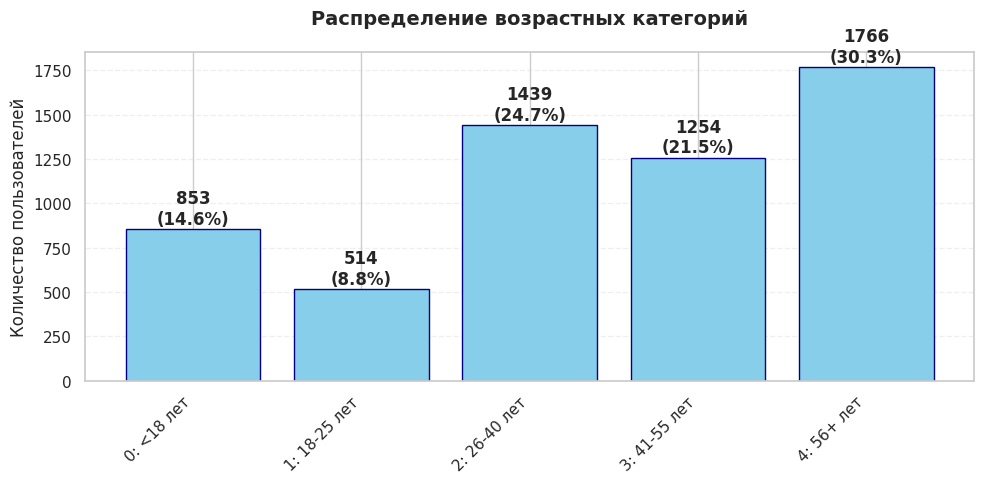

Всего: 5826 | Энтропия: 2.212 | Джини: 0.772 | Дисбаланс: 3.44:1


,count,pct
age_category,,
0: <18 лет,853,14.6
1: 18-25 лет,514,8.8
2: 26-40 лет,1439,24.7
3: 41-55 лет,1254,21.5
4: 56+ лет,1766,30.3



⚠️  Вывод: Критический дисбаланс (>2:1): нужен class_weight='balanced'.


In [64]:
counts = df_users[TARGET].value_counts().sort_index()
total = len(df_users)
pcts = (counts / total * 100).round(1)
probs = counts / total

# Метрики дисбаланса
entropy = -np.sum(probs * np.log2(probs))
gini = 1 - np.sum(probs ** 2)
imbalance_ratio = counts.max() / counts.min()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index.astype(str), counts.values, color='skyblue', edgecolor='navy')

for bar, cnt, pct in zip(bars, counts.values, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cnt}\n({pct}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Распределение возрастных категорий', fontsize=14, pad=20, fontweight='bold')
ax.set_ylabel('Количество пользователей')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Отчёт по метрикам
print("=" * 50)
print(f"Всего: {total} | Энтропия: {entropy:.3f} | Джини: {gini:.3f} | Дисбаланс: {imbalance_ratio:.2f}:1")

# распределение возрастов по категориям    
global_dist = pd.DataFrame({
    'count': counts,
    'pct': pcts
})
global_dist.index.name = TARGET

display(global_dist)

if imbalance_ratio > 2:
    print("\n⚠️  Вывод: Критический дисбаланс (>2:1): нужен class_weight='balanced'.")
elif imbalance_ratio > 1.5:
    print("\n⚠️  Вывод: Умеренный дисбаланс: рекомендуется class_weight='balanced'.")
else:
    print("\n✅  Вывод: Классы сбалансированы.")

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

👉 Максимальняа возможная энтропия для 5-ти классов log(5) = 2.32, а у нас 2.21, это 95% от максимума, поэтому, распределение по возрастам близко к равномерному, индекс Джинни тоже высокий и подтверждает. Дизбаланс 1766 / 514 = 3.44. Раз дизбаланс >2, то есть риск смещения модели в сторону доминирующего класса. Поэтому, надо использовать **class_weight='balanced' и стратификацию при разделении на выбрки.**

### Категория website_category в разрезе age_category

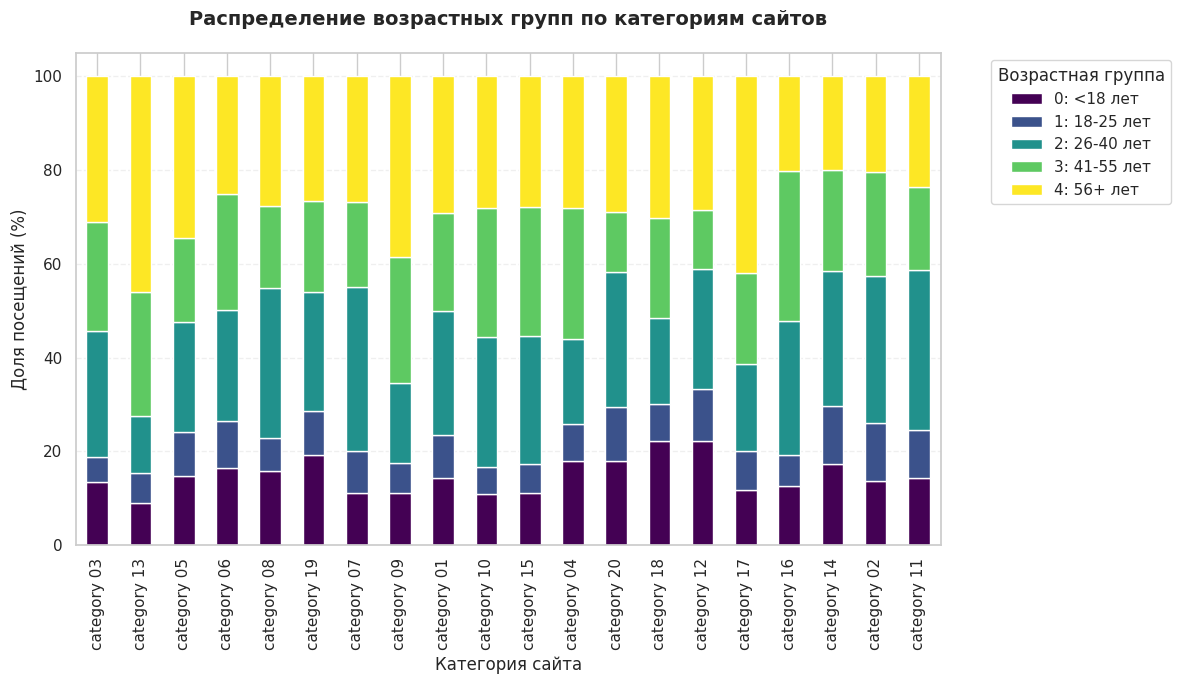

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
website_category,,,,,
category 03,13.5,5.4,26.7,23.4,31.0
category 13,8.9,6.6,12.0,26.4,46.1
category 05,14.7,9.5,23.4,17.9,34.5
category 06,16.5,10.0,23.6,24.7,25.2
category 08,15.8,7.0,32.1,17.4,27.7
category 19,19.2,9.4,25.5,19.3,26.6
category 07,11.2,8.9,34.9,18.1,26.9
category 09,11.1,6.3,17.1,26.9,38.6
category 01,14.4,9.1,26.5,20.8,29.2


In [65]:
visits_age = df_visits[['user_id', 'website_category']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# группировка и подсчет
age_by_category = visits_age.groupby(['website_category', TARGET], observed=False).size().unstack(fill_value=0)

# нормировка по строкам (доля каждой возрастной группы внутри категории)
age_by_category_pct = age_by_category.div(age_by_category.sum(axis=1), axis=0) * 100

# сортировка категорий по общему числу посещений (для удобства)
total_visits = age_by_category.sum(axis=1)
age_by_category_pct = age_by_category_pct.loc[total_visits.sort_values(ascending=False).index]

# stacked bar
ax = age_by_category_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
ax.set_title('Распределение возрастных групп по категориям сайтов', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Категория сайта')
ax.set_ylabel('Доля посещений (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(age_by_category_pct.round(1))

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно, при объединении таблиц нужно привязаться к уникальному `'user_id'`.</font>

In [66]:
wc_diff = deviation_table_from_cross(age_by_category_pct, global_dist)

print("\nТаблица разностей с распределением возрастов (в %):")
display(wc_diff)

print(f"Максимальное среднее абсолютное отклонение: {wc_diff['среднее_абс_откл'].max():.2f}%")
print(f"Усреднённое среднее абсолютное отклонение: {wc_diff['среднее_абс_откл'].mean():.2f}%")


Таблица разностей с распределением возрастов (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
website_category,,,,,,
category 13,-5.7,-2.2,-12.7,4.9,15.8,8.3
category 16,-2.0,-2.3,4.0,10.5,-10.2,5.8
category 09,-3.5,-2.5,-7.6,5.4,8.3,5.5
category 17,-2.8,-0.6,-6.0,-2.1,11.7,4.6
category 02,-0.9,3.6,6.5,0.8,-9.9,4.3
category 11,-0.2,1.4,9.4,-3.9,-6.6,4.3
category 12,7.6,2.3,0.8,-8.9,-1.7,4.3
category 14,2.7,3.6,4.0,0.2,-10.4,4.2
category 07,-3.4,0.1,10.2,-3.4,-3.4,4.1


Максимальное среднее абсолютное отклонение: 8.30%
Усреднённое среднее абсолютное отклонение: 3.81%


👉 **website_category** как уже видели выше, суммарные посещения распределены достаточно равномерно по категориям сайтов: 4% - 6% всех посещений приходится на каждую категорию. Большинство категорий имеют сильную разделяющую способность, особенно 13, 16 и 9. И две слабые: 1 и 3. И в среднем, у нас отклонение от распределения по возрастов **3.8%**, что существенно. Поэтому, добавим поля по всем категориям:

**`wcat_share_<cat_N>`** - доля посещений пользователя для категории сайтов.
Признак сильный. Можно было бы удалить категории с max отклонением < 4, но мы применим отбор признаков позже, после разделения на выборки, и там слабые поля отсеятся.

### Категория daytime в разрезе age_category

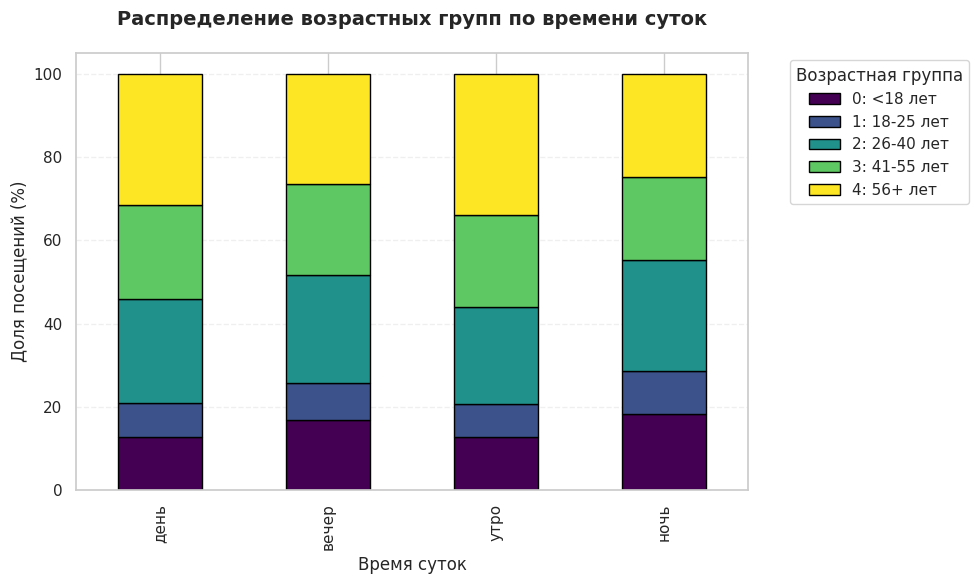

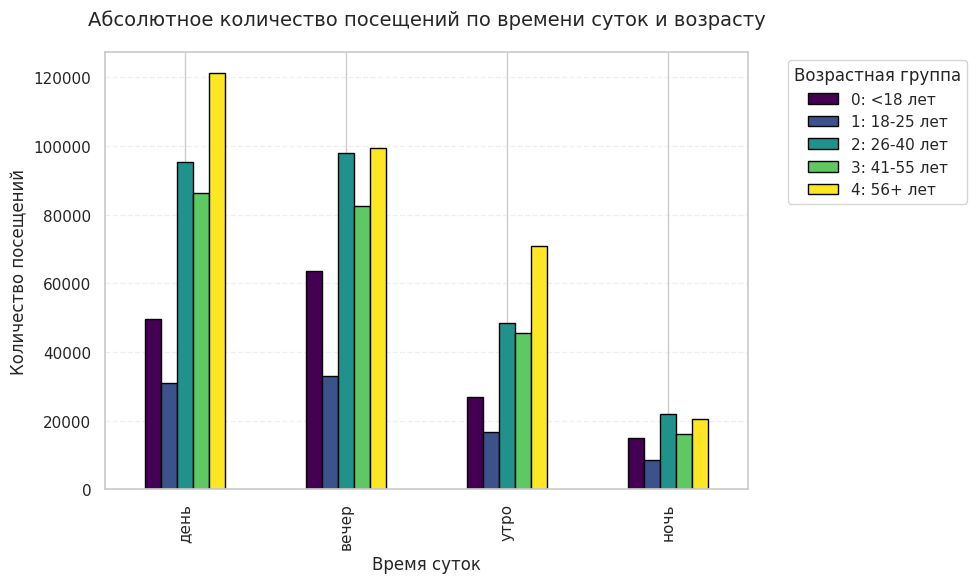

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
daytime,,,,,
день,12.9,8.1,24.9,22.5,31.6
вечер,16.9,8.8,26.0,21.9,26.4
утро,12.8,8.0,23.3,21.9,34.0
ночь,18.3,10.3,26.8,19.7,24.9


In [67]:
visits_age_daytime = df_visits[['user_id', 'daytime']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# таблица сопряжённости (время суток × возраст)
cross_daytime = pd.crosstab(visits_age_daytime['daytime'], visits_age_daytime[TARGET])

# сортировка по общей посещаемости
total_visits_daytime = cross_daytime.sum(axis=1)
cross_daytime_sorted = cross_daytime.loc[total_visits_daytime.sort_values(ascending=False).index]

# доли по строкам (%)
cross_daytime_pct = cross_daytime_sorted.div(cross_daytime_sorted.sum(axis=1), axis=0) * 100

# Stacked bar – доли возрастных групп внутри каждого времени суток
fig, ax = plt.subplots(figsize=(10, 6))
cross_daytime_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Распределение возрастных групп по времени суток', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Время суток')
ax.set_ylabel('Доля посещений (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Grouped bar – абсолютные числа посещений (для оценки объёмов)
cross_daytime_sorted.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Абсолютное количество посещений по времени суток и возрасту', fontsize=14, pad=20)
plt.xlabel('Время суток')
plt.ylabel('Количество посещений')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(cross_daytime_pct.round(1))

In [68]:
dt_diff = deviation_table_from_cross(cross_daytime_pct, global_dist)

print("\nТаблица разностей с распределением возрастов (в %):")
display(dt_diff)

print(f"Максимальное среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].max():.2f}%")
print(f"Усреднённое среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].mean():.2f}%")


Таблица разностей с распределением возрастов (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
daytime,,,,,,
ночь,3.7,1.5,2.1,-1.8,-5.4,2.9
утро,-1.8,-0.8,-1.4,0.4,3.7,1.6
вечер,2.3,-0.0,1.3,0.4,-3.9,1.6
день,-1.7,-0.7,0.2,1.0,1.3,1.0


Максимальное среднее абсолютное отклонение: 2.90%
Усреднённое среднее абсолютное отклонение: 1.77%


👉 Распределение **daytime** по возрасту внутри каждой группы очень близкое. Наиболее разделяющая у нас ночь. Там отклонение от распределения возрастов в датасете - максимально: 2.9%. Поэтому, переменная не очень сильная. Среднее отклонение 1.77% против 3.8% у website_category.

Включим поле **`dt_share_<daytime>`** - доля посещений от общего числа посещений в группе по user_id, но вероятно оно **отсеится.**

### Категория ads_activity в разрезе age_category

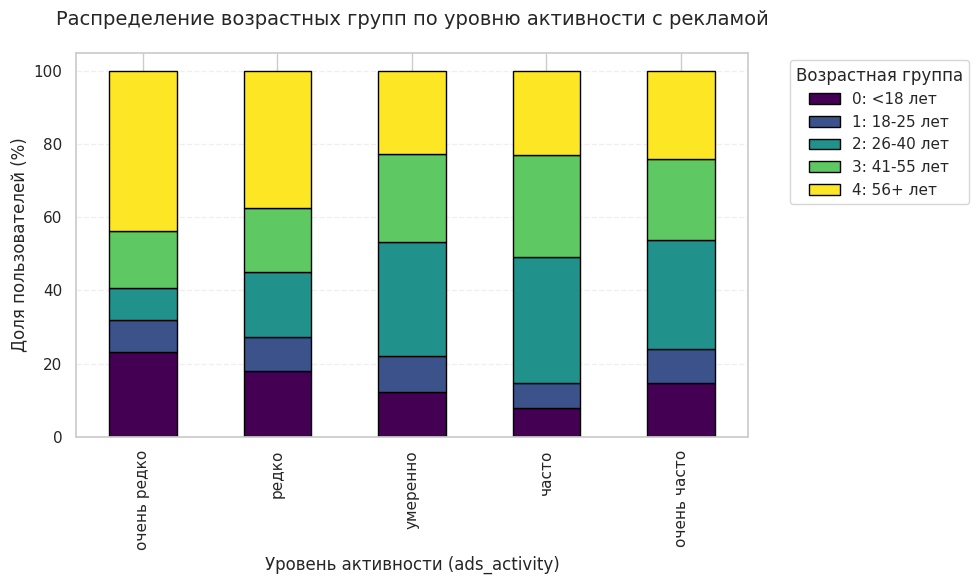

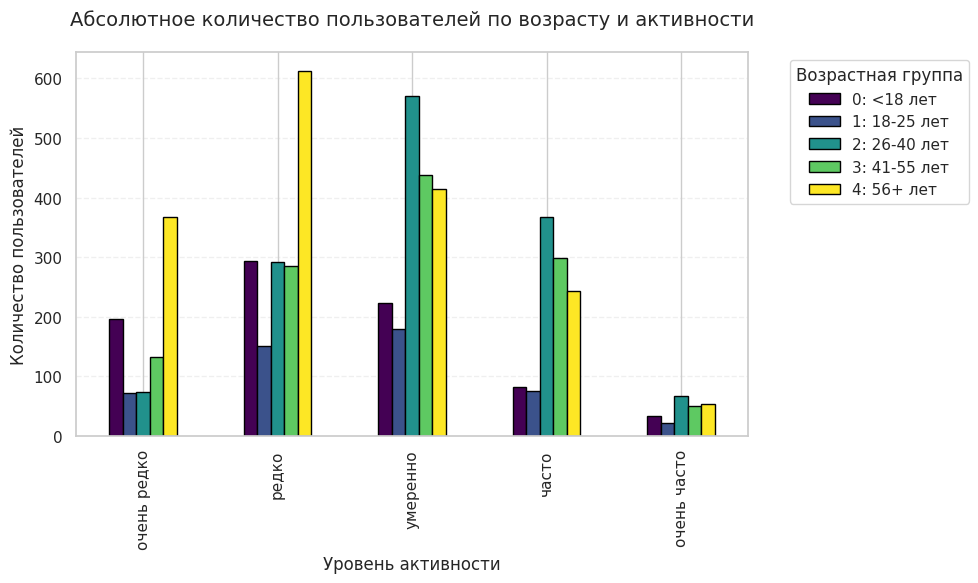

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
ads_activity,,,,,
очень редко,23.3,8.6,8.8,15.7,43.6
редко,17.9,9.2,17.9,17.4,37.5
умеренно,12.2,9.8,31.2,24.0,22.7
часто,7.8,7.0,34.4,28.0,22.8
очень часто,14.7,9.3,29.8,22.2,24.0


In [69]:
ads_age = df_ads[['user_id', 'ads_activity']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# порядок категорий (от редкой к частой)
order = ['очень редко', 'редко', 'умеренно', 'часто', 'очень часто']
ads_age['ads_activity'] = pd.Categorical(ads_age['ads_activity'], categories=order, ordered=True)

# строим таблицу сопряжённости
cross = pd.crosstab(ads_age['ads_activity'], ads_age[TARGET])

# нормализация по строкам
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

# Stacked bar
fig, ax = plt.subplots(figsize=(10, 6))
cross_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Распределение возрастных групп по уровню активности с рекламой', fontsize=14, pad=20)
ax.set_xlabel('Уровень активности (ads_activity)')
ax.set_ylabel('Доля пользователей (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Grouped bar (абсолютные числа)
cross.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Абсолютное количество пользователей по возрасту и активности', fontsize=14, pad=20)
plt.xlabel('Уровень активности')
plt.ylabel('Количество пользователей')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(cross_pct.round(1))

In [70]:
dt_diff = deviation_table_from_cross(cross_pct, global_dist)

print("\nТаблица разностей с распределением возрастов (в %):")
display(dt_diff)

print(f"Максимальное среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].max():.2f}%")
print(f"Усреднённое среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].mean():.2f}%")


Таблица разностей с распределением возрастов (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
ads_activity,,,,,,
очень редко,8.7,-0.2,-15.9,-5.8,13.3,8.8
часто,-6.8,-1.8,9.7,6.5,-7.5,6.5
редко,3.3,0.4,-6.8,-4.1,7.2,4.4
умеренно,-2.4,1.0,6.6,2.5,-7.6,4.0
очень часто,0.1,0.5,5.1,0.7,-6.3,2.5


Максимальное среднее абсолютное отклонение: 8.80%
Усреднённое среднее абсолютное отклонение: 5.24%


👉 **ads_activity** демонстрирует смещение числа возростов в группах. В "редко" и "очень редко" выше доля старших. А в "часто" и "очень часто" доли молодёжи. Признак показывает хорошую разделяющую способность, сравнимую с website_category, так как среднее отклонение **5.24%** против 3.81% website_category.

**Будем его включать** в датасет, используя Order encoding (0, 1, 2, 3, 4).

### Категория surf_depth в разрезе age_category

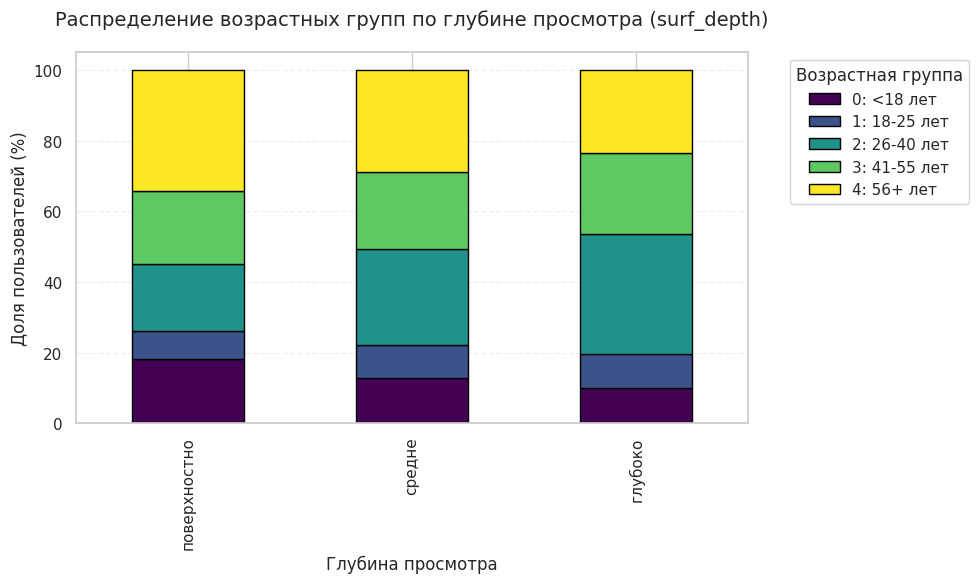

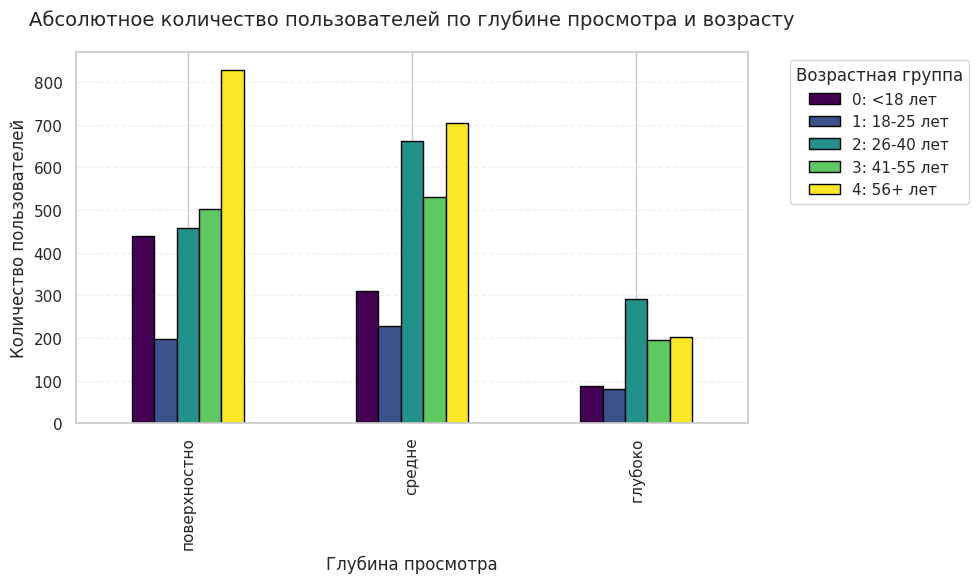

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
surf_depth,,,,,
поверхностно,18.1,8.1,18.9,20.8,34.2
средне,12.8,9.3,27.2,21.8,28.9
глубоко,10.0,9.5,34.0,22.9,23.6


In [71]:
surf_age = df_surf[['user_id', 'surf_depth']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# порядок категорий (от поверхностного к глубокому)
order_depth = ['поверхностно', 'средне', 'глубоко']
surf_age['surf_depth'] = pd.Categorical(surf_age['surf_depth'], categories=order_depth, ordered=True)

# таблица сопряжённости (глубина × возраст)
cross_depth = pd.crosstab(surf_age['surf_depth'], surf_age[TARGET])

# доли по строкам (%)
cross_depth_pct = cross_depth.div(cross_depth.sum(axis=1), axis=0) * 100

# Stacked bar – возрастной состав внутри каждой группы глубины
fig, ax = plt.subplots(figsize=(10, 6))
cross_depth_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Распределение возрастных групп по глубине просмотра (surf_depth)', fontsize=14, pad=20)
ax.set_xlabel('Глубина просмотра')
ax.set_ylabel('Доля пользователей (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Grouped bar – абсолютные количества пользователей
cross_depth.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Абсолютное количество пользователей по глубине просмотра и возрасту', fontsize=14, pad=20)
plt.xlabel('Глубина просмотра')
plt.ylabel('Количество пользователей')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(cross_depth_pct.round(1))

In [72]:
dt_diff = deviation_table_from_cross(cross_depth_pct, global_dist)

print("\nТаблица разностей с распределением возрастов (в %):")
display(dt_diff)

print(f"Максимальное среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].max():.2f}%")
print(f"Усреднённое среднее абсолютное отклонение: {dt_diff['среднее_абс_откл'].mean():.2f}%")


Таблица разностей с распределением возрастов (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
surf_depth,,,,,,
глубоко,-4.6,0.7,9.3,1.4,-6.7,4.5
поверхностно,3.5,-0.7,-5.8,-0.7,3.9,2.9
средне,-1.8,0.5,2.5,0.3,-1.4,1.3


Максимальное среднее абсолютное отклонение: 4.50%
Усреднённое среднее абсолютное отклонение: 2.90%


👉 **surf_depth** указывает на немонотонную, но значимую связь между глубиной просмотра и возрастом: молодые пользователи (<18) чаще просматривают поверхностно, пользователи среднего возраста (26–40) – глубже, а пожилые (56+) тоже склонны к поверхностному просмотру.

**Будем включать** данный признак. Хотя, разделение умеренное: **2.9%**, ниже, чем у ads_activity и website_category. Можно использовать **Order encoding** (0 – поверхностно, 1 – средне, 2 – глубоко).

### Категория primary_device в разрезе age_category

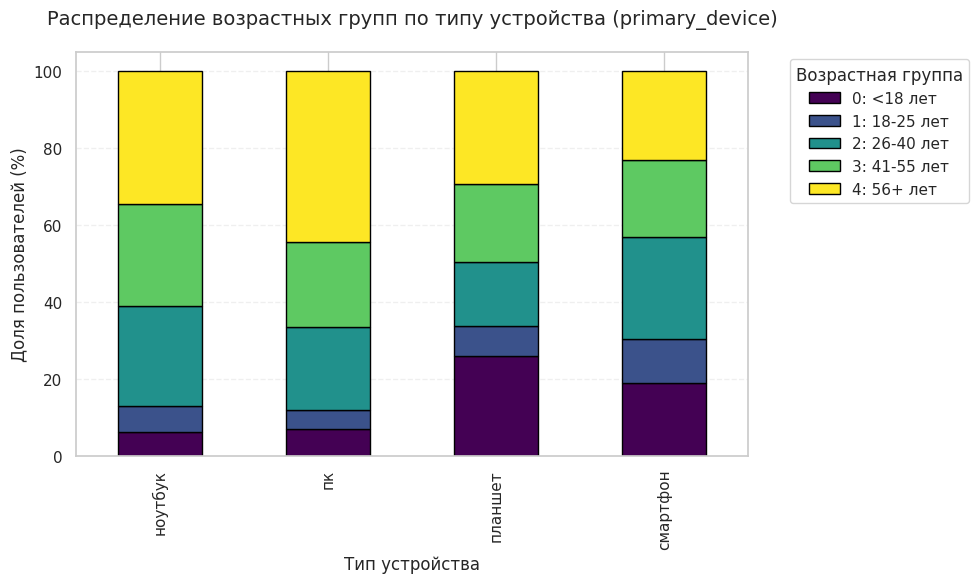

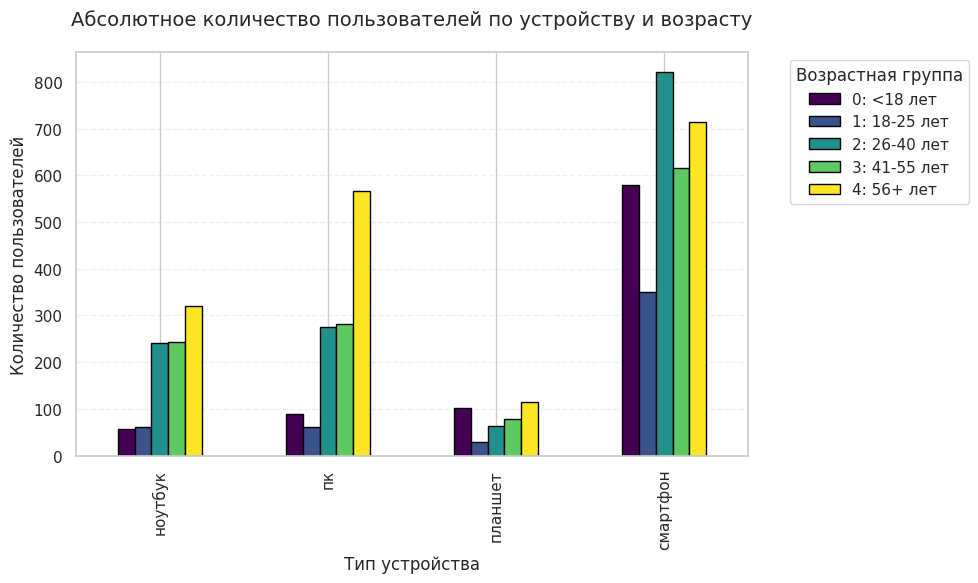

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
primary_device,,,,,
ноутбук,6.2,6.6,26.2,26.3,34.7
пк,7.0,4.9,21.6,22.1,44.5
планшет,26.0,7.7,16.5,20.4,29.4
смартфон,18.8,11.4,26.7,19.9,23.2


In [73]:
device_age = df_device[['user_id', 'primary_device']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# кросс-таблица (устройство × возраст)
cross_device = pd.crosstab(device_age['primary_device'], device_age[TARGET])

# доли по строкам (%)
cross_device_pct = cross_device.div(cross_device.sum(axis=1), axis=0) * 100

# Stacked bar – возрастной состав для каждого устройства
fig, ax = plt.subplots(figsize=(10, 6))
cross_device_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Распределение возрастных групп по типу устройства (primary_device)', fontsize=14, pad=20)
ax.set_xlabel('Тип устройства')
ax.set_ylabel('Доля пользователей (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Grouped bar – абсолютные количества
cross_device.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Абсолютное количество пользователей по устройству и возрасту', fontsize=14, pad=20)
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

display(cross_device_pct.round(1))

In [74]:
# таблица разностей (используя глобальное распределение из global_dist)
dev_device = deviation_table_from_cross(cross_device_pct, global_dist)

print("\nТаблица разностей для primary_device (в %):")
display(dev_device)

max_dev = dev_device['среднее_абс_откл'].max()
avg_dev = dev_device['среднее_абс_откл'].mean()
print(f"Максимальное среднее абсолютное отклонение: {max_dev:.2f}%")
print(f"Среднее среднее абсолютное отклонение: {avg_dev:.2f}%")


Таблица разностей для primary_device (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
primary_device,,,,,,
пк,-7.6,-3.9,-3.1,0.6,14.2,5.9
планшет,11.4,-1.1,-8.2,-1.1,-0.9,4.6
ноутбук,-8.4,-2.2,1.5,4.8,4.4,4.3
смартфон,4.2,2.6,2.0,-1.6,-7.1,3.5


Максимальное среднее абсолютное отклонение: 5.90%
Среднее среднее абсолютное отклонение: 4.58%


👉 **primary_device** - это сильный призеак, среднее отклонение от распределения пользователей по возрастам **4.58%** - это хороший результат. **Будем включать** в датасет используя One Hot encoding.

### Бинарный cloud_usage в разрезе age_category

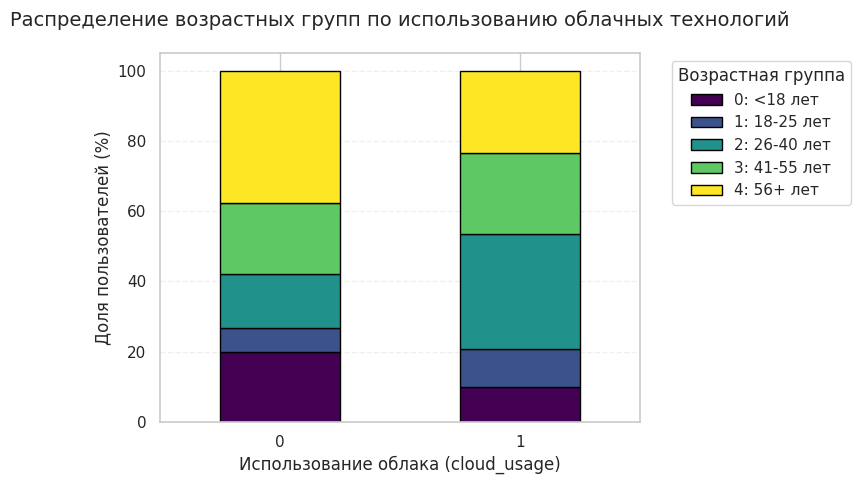

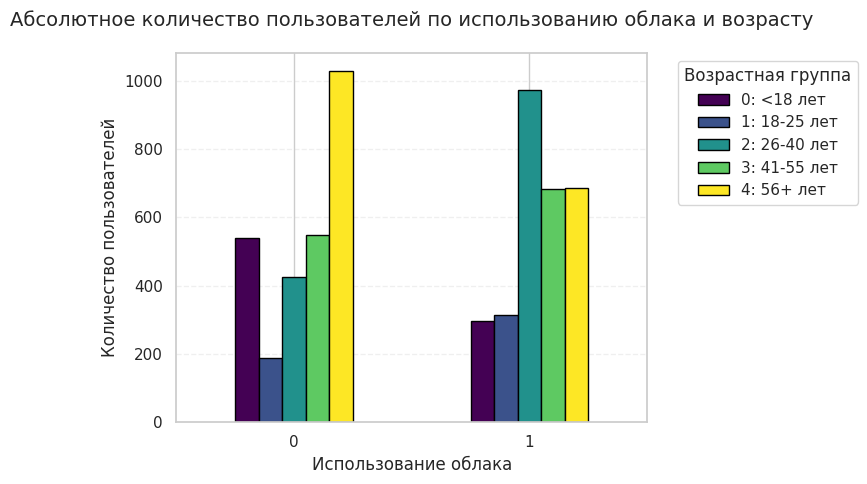

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
cloud_usage,,,,,
0,19.8,6.9,15.5,20.1,37.7
1,10.0,10.7,32.9,23.1,23.2


In [75]:
cloud_age = df_cloud[['user_id', 'cloud_usage']].merge(
    df_users[['user_id', TARGET]], on='user_id', how='inner'
)

# 2. Кросс-таблица (cloud_usage × возраст)
cross_cloud = pd.crosstab(cloud_age['cloud_usage'], cloud_age[TARGET])

# 3. Доли по строкам (%)
cross_cloud_pct = cross_cloud.div(cross_cloud.sum(axis=1), axis=0) * 100

# 4. Stacked bar – возрастной состав для каждой группы cloud_usage
fig, ax = plt.subplots(figsize=(8, 5))
cross_cloud_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Распределение возрастных групп по использованию облачных технологий', fontsize=14, pad=20)
ax.set_xlabel('Использование облака (cloud_usage)')
ax.set_ylabel('Доля пользователей (%)')
ax.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Grouped bar – абсолютные количества
cross_cloud.plot(kind='bar', figsize=(8, 5), colormap='viridis', edgecolor='black')
plt.title('Абсолютное количество пользователей по использованию облака и возрасту', fontsize=14, pad=20)
plt.xlabel('Использование облака')
plt.ylabel('Количество пользователей')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(cross_cloud_pct.round(1))

In [76]:
dev_cloud = deviation_table_from_cross(cross_cloud_pct, global_dist)

print("\nТаблица разностей для cloud_usage (в %):")
display(dev_cloud)

max_dev = dev_cloud['среднее_абс_откл'].max()
avg_dev = dev_cloud['среднее_абс_откл'].mean()
print(f"Максимальное среднее абсолютное отклонение: {max_dev:.2f}%")
print(f"Среднее среднее абсолютное отклонение: {avg_dev:.2f}%")


Таблица разностей для cloud_usage (в %):


age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет,среднее_абс_откл
cloud_usage,,,,,,
0,5.2,-1.9,-9.2,-1.4,7.4,5.0
1,-4.6,1.9,8.2,1.6,-7.1,4.7


Максимальное среднее абсолютное отклонение: 5.00%
Среднее среднее абсолютное отклонение: 4.85%


👉 **cloud_usage** - имеет неплохую разделяющую способность, разность **4.85%**. Пожилые реже используют облачные сервисы, а средний возраст чаще всего.

**Будем включать** в датасет как есть.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Предобработка данных

### Замена датасета visits скалярными признаками для каждого отдельного пользователя

user_id может иметь много связанных записей в датасете df_visits. Поэтому, чтобы использовать эти важные логи, мы **сагрегируем их в набор скалярных величин** для каждого пользователя индивидуально. Сначала проверим, есть ли у нас пользователи из df_users без логов посещений.

In [77]:
users_without_logs = df_users[~df_users['user_id'].isin(df_visits["user_id"].unique())]
display(users_without_logs)

,user_id,age_category


👉 В нашем случае таких строк в users нет. Однако, есть риск, что в другой выборке могут появиться, и тогда мы потеряем много важных полей. Будем **удалять такие user_id без логов** из users.

👉 Добавить в трансформер исключение users без логов.

In [78]:
df_users = df_users.drop(users_without_logs.index).reset_index(drop=True)
print(f'Удалено {len(users_without_logs)} строк из users: {len(users_without_logs) / len(df_users):.1%}')

Удалено 0 строк из users: 0.0%


### Предполагаемые признаки

#### Объём и интенсивность активности
| Признак | Тип | Описание |
|---|---|---|
| `total_visits` | `count` | Общее число посещений |
| `n_sessions` | `count` | Число уникальных сессий |
| `visits_per_session` | `ratio` | Средняя глубина сессии (действий за сессию) |
| `visits_per_day` | `ratio` | Средняя интенсивность в активный день |

#### Временна́я активность и регулярность
| Признак | Тип | Описание |
|---|---|---|
| `n_active_days` | `count` | Число дней с активностью |
| `span_days` | `count` | Период между первым и последним визитом |
| `activity_density` | `ratio` | Регулярность: активные дни / весь период |
| `weekend_share` | `share` | Доля посещений в выходные |

#### Распределение по времени суток 
| Признак | Тип | Описание |
|---|---|---|
| `dt_share_утро` | `share` | Доля посещений утром |
| `dt_share_день` | `share` | Доля посещений днём |
| `dt_share_вечер` | `share` | Доля посещений вечером |
| `dt_share_ночь` | `share` | Доля посещений ночью |

#### Интересы по категориям сайтов
| Признак | Тип | Описание |
|---|---|---|
| `wcat_share_<cat_1>` | `share` | Доля посещений категории 1 |
| `wcat_share_<cat_2>` | `share` | Доля посещений категории 2 |
| `...` | `...` | `...` |
| `wcat_share_<cat_20>` | `share` | Доля посещений категории 20 |

#### Разнообразие поведения
| Признак | Тип | Описание |
|---|---|---|
| `n_unique_categories` | `count` | Число разных посещённых категорий |
| `wcat_entropy` | `float` | Энтропия распределения по категориям |

#### Рекламная активность (Ads CTR)
| Признак | Тип | Описание |
|---|---|---|
| `ads_activity_ord` | `ordinal` | CTR-активность, 0 (очень редко) … 4 (очень часто) |

In [79]:
main_stat = (df_visits.groupby('user_id').agg(
    total_visits = ('session_id', 'size'),
    n_sessions = ('session_id', 'nunique'),
    n_unique_categories = ('website_category', 'nunique'),
    n_active_days = ('date', 'nunique')
).reset_index()
    .assign(
        visits_per_session = lambda df: np.where(df['n_sessions'].eq(0), 0, df['total_visits'] / df['n_sessions']),
        visits_per_day = lambda df: np.where(df['n_active_days'].eq(0), 0, df['total_visits'] / df['n_active_days'])
    )
)

daytime = pd.crosstab(df_visits['user_id'], df_visits['daytime'], normalize='index').add_prefix('dt_share_')

In [80]:
wcat = pd.crosstab(df_visits['user_id'], df_visits['website_category'], normalize='index').add_prefix('wcat_share_')
# в данных перед номером пробел
wcat.columns = wcat.columns.str.replace(' ', '_')

m = wcat.values
safe_m = np.where(m > 0, m, 1.0)
wcat["wcat_entropy"] = -(m * np.log(safe_m)).sum(axis = 1)

In [81]:
date_stats = df_visits.groupby("user_id")["date"].agg(["min", "max"])
date_stats["span_days"] = (date_stats["max"] - date_stats["min"]).dt.days + 1

df_visits['is_weekend'] = (df_visits['date'].dt.dayofweek >= 5).astype('int8')
date_stats["weekend_share"] = df_visits.groupby("user_id")['is_weekend'].mean()
date_stats = date_stats[["span_days", "weekend_share"]]
df_visits.drop(columns=['is_weekend'], inplace=True)

In [82]:
features = (
    main_stat.set_index("user_id")
       .join(daytime)
       .join(wcat)
       .join(date_stats)       
       .fillna(0)
)

features["activity_density"] = features["n_active_days"] / features["span_days"].clip(lower=1)

In [83]:
del main_stat, daytime, wcat, date_stats
gc.collect()

35586

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

✅ Получили новые признаки пользователя на основе агрегации visits в DataFrame features.

👉 Добавить в pre_transform.

#### Проверка корреляции между новыми признаками

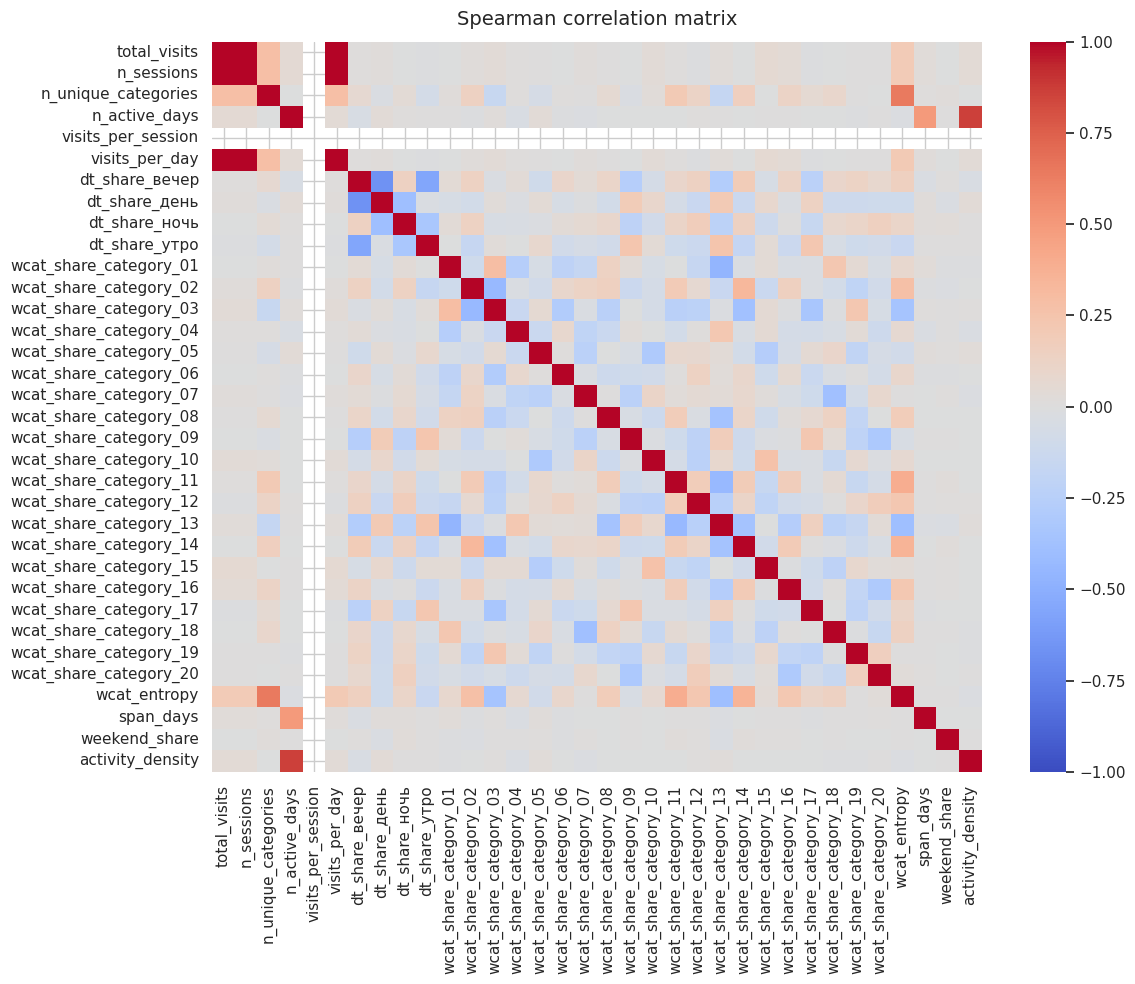

In [84]:
corr = features.corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title("Spearman correlation matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [85]:
print_high_corr_spearman_pairs(corr);


СИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Spearman |rho| > 0.7):
------------------------------------------------------------
n_sessions           <---> total_visits         | Spearman: 1.0000
total_visits         <---> visits_per_day       | Spearman: 0.9999
n_sessions           <---> visits_per_day       | Spearman: 0.9999
activity_density     <---> n_active_days        | Spearman: 0.8659
------------------------------------------------------------


In [86]:
features["visits_per_session"].describe()

count    5826.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: visits_per_session, dtype: float64

👉 Не все производные признаки полезны для обучения модели:
 - n_sessions, total_visits, n_active_days, span_days - зависят от размера выборки и будут сбивать модель;
 - visits_per_session - константный признак;

In [87]:
features.drop(columns=['n_sessions', 'total_visits', 'n_active_days', 'span_days', 'visits_per_session'], inplace=True)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

✅ Удалили лишние колонки.

In [88]:
corr = features.corr(method="spearman")
print_high_corr_spearman_pairs(corr);


СИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Spearman |rho| > 0.7):
------------------------------------------------------------
✅ Сильно скоррелированных пар с |Spearman| > 0.7 не обнаружено.
------------------------------------------------------------


👉 Теперь проверим мультиколлениарность.

In [89]:
check_vif(features, features.columns)

/opt/conda/envs/review_env/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
2,dt_share_вечер,inf
4,dt_share_ночь,inf
3,dt_share_день,inf
6,wcat_share_category_01,inf
5,dt_share_утро,inf
9,wcat_share_category_04,inf
10,wcat_share_category_05,inf
7,wcat_share_category_02,inf
8,wcat_share_category_03,inf
11,wcat_share_category_06,inf


👉 Надо убрать по одному признаку из каждой полной группы. Например: dt_share_утро. Его можно восстановить по трём остальным признакам: день, вечер, ночь. Из категорий удалим слабую wcat_share_category_01. Из временных признаков удалим самый слабый: dt_share_день.

In [90]:
drop_columns_inplace_safe(features, ('wcat_share_category_01', 'dt_share_день',))

In [91]:
check_vif(features, features.columns)

,Feature,VIF
6,wcat_share_category_03,8.814595
16,wcat_share_category_13,5.094876
21,wcat_share_category_18,3.480525
20,wcat_share_category_17,3.350712
11,wcat_share_category_08,3.159256
5,wcat_share_category_02,3.110065
23,wcat_share_category_20,2.959646
12,wcat_share_category_09,2.918858
24,wcat_entropy,2.801837
17,wcat_share_category_14,2.798565


✅ Убрали все лишние колонки, теперь VIF < 10, значит мульиколлениарности нет.

👉 Секцию для новых фич добавить в pre_transformer.

### Создание единого рабочего датасета для обучения модели
Теперь в новых признаках нет сильной коллинеарности и мультиколлениарности, поэтому, можно смёржить итоговый датасет.

In [92]:
df_main = (
    df_users.merge(df_ads, on='user_id', how='left')    
    .merge(df_surf, on='user_id', how='left')
    .merge(df_device, on='user_id', how='left')
    .merge(df_cloud, on='user_id', how='left')
    .merge(features, left_on='user_id', right_index=True, how='inner')
)

In [93]:
del df_ads, df_surf, df_cloud, features, df_users, df_visits
gc.collect()

3955

✅ Построили рабочий датасет.

👉 Добавить в pre_transform.

#### Проверка рабочего датасета и очистка

In [94]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 5825
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   user_id                 5826 non-null   string  
 1   age_category            5826 non-null   category
 2   ads_activity            5593 non-null   category
 3   surf_depth              5715 non-null   category
 4   primary_device          5669 non-null   category
 5   cloud_usage             5680 non-null   float64 
 6   n_unique_categories     5826 non-null   int64   
 7   visits_per_day          5826 non-null   float64 
 8   dt_share_вечер          5826 non-null   float64 
 9   dt_share_ночь           5826 non-null   float64 
 10  dt_share_утро           5826 non-null   float64 
 11  wcat_share_category_02  5826 non-null   float64 
 12  wcat_share_category_03  5826 non-null   float64 
 13  wcat_share_category_04  5826 non-null   float64 
 14  wcat_share_category_05  5826 

In [95]:
missing = df_main.isna().sum()
missing = missing[missing > 0]
display(missing)

ads_activity      233
surf_depth        111
primary_device    157
cloud_usage       146
dtype: int64

👉 Типы данных не все оптимальные. cloud_usage бинарное поле, надо заполнить пропуски **-1** и привести к int8.
В категорийных полях с пропуском надо добавить категорию **unknown** и заполнить ей пропуски.

In [96]:
df_main['activity_density'].value_counts()

activity_density
1.000000    5820
0.928571       6
Name: count, dtype: int64

👉 Так же, теперь можно удалить технологическую колонку user_id, она не нужна для обучения модели.
И, видим, что activity_density почти константа. Его тоже можно удалить.

Ещё проверим **n_unique_categories**.

In [97]:
df_main['n_unique_categories'].value_counts()

n_unique_categories
19    3561
18    1619
17     509
16     116
15      19
14       2
Name: count, dtype: int64

In [98]:
print(df_main["n_unique_categories"].corr(df_main["wcat_entropy"], method="spearman"))

0.6459581763231362


In [99]:
# Проверяем силу связи с TARGET: насколько признаки полезны для разделения классов.
mi = mutual_info_classif(
    df_main[['n_unique_categories', 'wcat_entropy']],
    df_main[TARGET],
    discrete_features=[True, False],   # count дискретный, entropy непрерывная
    random_state=42
)
print(pd.Series(mi, index=['n_unique_categories', 'wcat_entropy']))

n_unique_categories    0.007373
wcat_entropy           0.032423
dtype: float64


👉 У **n_unique_categories** получилась низкая вариативность, средняя корреляция с entropy и очень низкая корреляция с TARGET. Поэтому, удалим его и оставим более сильный признак **wcat_entropy**.

In [100]:
df_main.drop(columns=['user_id', 'activity_density', 'n_unique_categories'], inplace=True)

✅ Удалили **user_id и константу activity_density, n_unique_categories**.

👉 Это добавить в трансформеры.

In [101]:
# Теперь можем описать все признаки, чтобы было легко использовать их далее.
BINARY_VARS = ('cloud_usage',) # после заполнения пропусков -1 это псевдо-бинарный признак
CATEGORY_VARS = ('ads_activity', 'surf_depth', 'primary_device')

CONTINIOUS_VARS = set(df_main.columns) - (set(BINARY_VARS) | set(CATEGORY_VARS) | set([TARGET]))
print('Непрерывные переменные:', CONTINIOUS_VARS)

Непрерывные переменные: {'wcat_share_category_08', 'weekend_share', 'dt_share_ночь', 'wcat_share_category_20', 'wcat_share_category_04', 'wcat_share_category_16', 'dt_share_вечер', 'wcat_share_category_17', 'wcat_share_category_14', 'wcat_share_category_02', 'dt_share_утро', 'wcat_share_category_13', 'wcat_share_category_05', 'wcat_share_category_10', 'wcat_share_category_15', 'wcat_share_category_09', 'wcat_share_category_19', 'wcat_entropy', 'wcat_share_category_06', 'visits_per_day', 'wcat_share_category_03', 'wcat_share_category_11', 'wcat_share_category_12', 'wcat_share_category_18', 'wcat_share_category_07'}


In [102]:
for col in CATEGORY_VARS:
    if df_main[col].isna().any():
        if 'unknown' not in df_main[col].cat.categories:
            df_main[col] = df_main[col].cat.add_categories(['unknown'])
            df_main[col] = df_main[col].fillna('unknown')
            
df_main['cloud_usage'] = df_main['cloud_usage'].fillna(-1).astype('int8')

In [103]:
# проверяем пропуски
df_main.isna().any().any()

False

✅ Заполнили пропуски и привели типы.

👉 Это добавить в трансформеры.

👉 На этом pre_transform заканчивается.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Дополнительный анализ рабочего датасета
Теперь нужно решить, как кодировать признаки датасета для обучения моделей.

#### Категориальные признаки

В категорийных переменных у нас небольшая кардинальность, для заполнения пропусков добавили категорию unknown, поэтому, даже в тех из них, где сть порядок (ads_activity) он нарушился. Кроме того, ранее, при анализе в некоторых из них в разрезе TARGET есть нарушение монотонности. 

👉 Поэтому, будем все кодировать через **One Hot Encoding**.

У cloud_usage будем удалять категорию 0, так как это вариант по-умолчанию, а -1 - добавленный вместо пропусков.

#### Бинарные признаки

In [104]:
pd.crosstab(df_main['cloud_usage'], df_main['age_category'], normalize='index')

age_category,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
cloud_usage,,,,,
-1,0.123288,0.075342,0.294521,0.150685,0.356164
0,0.197875,0.068890,0.155368,0.201173,0.376695
1,0.099966,0.106743,0.329380,0.231447,0.232464


👉 Связь по -1 --> 0 --> 1, профиль unknown не совпадает с 0 или 1, поэтому, нельзя оставлять числом.

👉 Будем использовать **One Hot Encoding**.

#### Непрерывные признаки
Тут у нас все новые производные признаки, поэтому, надо проверить на выбросы.

In [105]:
cont_cols = sorted(CONTINIOUS_VARS)

summary = pd.DataFrame({
    'skew':       df_main[cont_cols].skew(),
    'skew_log1p': df_main[cont_cols].apply(lambda s: np.log1p(s).skew()),
    'zero_share': (df_main[cont_cols] == 0).mean(),
    'median':     df_main[cont_cols].median(),
    'q99':        df_main[cont_cols].quantile(0.99),
    'max':        df_main[cont_cols].max(),
})
summary['max_to_q99'] = summary['max'] / summary['q99'].replace(0, np.nan)


def decide_encoding(row):
    # сильная скошенность, которую лечит log
    if abs(row['skew']) > 1 and abs(row['skew_log1p']) < abs(row['skew']):
        return 'log1p + RobustScaler'
    
    # сильные выбросы без пользы от log
    if row['max_to_q99'] > 2:
        return 'RobustScaler'
    
    # бимодальность из-за нулей
    if row['zero_share'] > 0.40:
        return 'QuantileTransformer'
    
    return 'StandardScaler'

summary['encoding'] = summary.apply(decide_encoding, axis=1)

print(summary[['skew','skew_log1p','zero_share','max_to_q99','encoding']]
      .sort_values('skew', ascending=False)
      .round(3))

                         skew  skew_log1p  zero_share  max_to_q99  \
visits_per_day          1.931       0.565       0.000       1.912   
wcat_share_category_11  0.713       0.642       0.113       1.552   
wcat_share_category_13  0.676       0.578       0.230       1.373   
wcat_share_category_18  0.670       0.585       0.069       1.455   
wcat_share_category_10  0.617       0.524       0.043       1.712   
wcat_share_category_16  0.610       0.535       0.075       1.336   
wcat_share_category_04  0.591       0.505       0.039       1.474   
wcat_share_category_03  0.553       0.455       0.175       1.289   
wcat_share_category_02  0.536       0.467       0.111       1.529   
wcat_share_category_17  0.525       0.452       0.059       1.528   
wcat_share_category_20  0.506       0.433       0.053       1.438   
wcat_share_category_14  0.500       0.429       0.106       1.583   
wcat_share_category_09  0.469       0.388       0.039       1.480   
dt_share_ночь           0.438     

👉 По skew и параметрам распределения признаков подобрали энкодеры непрерывных числовых признаков. visits_per_day вызывает подозрения, поэтому посмотрим его ящики с усами по классам TARGET.

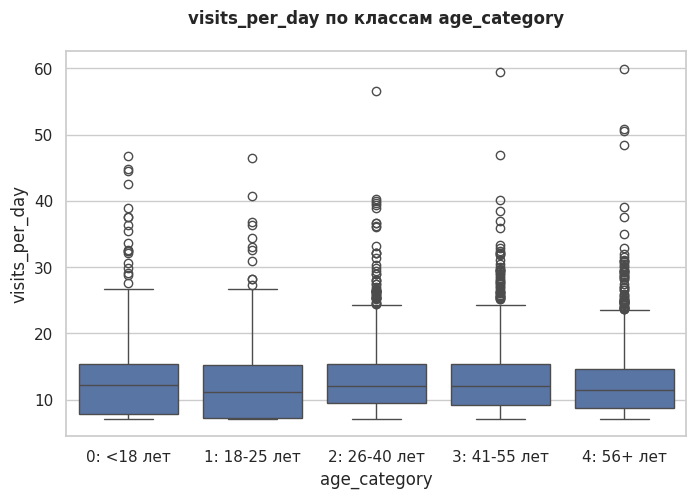

In [106]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_main, x=TARGET, y="visits_per_day")
plt.title(f"visits_per_day по классам {TARGET}", pad=20, weight='bold')
plt.show()

| Группа признаков | Признаки | Тип данных | Тип признака | Энкодинг | Параметры / обоснование |
|---|---|---|---|---|---|
| Таргет | `age_category` | `category` | таргет | — | Целевая переменная, не кодируется. |
| Категориальные номинальные | `ads_activity`, `surf_depth`, `primary_device` | `category` | номинальный / номинальный* | `OneHotEncoder` | `drop='first'`, `handle_unknown='ignore'`. |
| Псевдо-бинарный | `cloud_usage` | `int8 {-1,0,1}` | псевдо-бинарный | `OneHotEncoder` | `categories=[[-1,0,1]]`, `drop=[0]`, `handle_unknown='ignore'`. |
| Непрерывный с выбросами | `visits_per_day` | `float64` | непрерывный, выбросы | `log1p → RobustScaler` | `skew>1`, log снижает скошенность; `max > q99`. |
| Доли по времени суток | `dt_share_вечер`, `dt_share_ночь`, `dt_share_утро` | `float64` | непрерывный (доля) | `StandardScaler` | Симметричны, выбросов нет; `dt_share_день` удалён (`drop_first`). |
| Доли по категориям wcat | `wcat_share_category_02`–`wcat_share_category_20` | `float64` | непрерывный (доля) | `StandardScaler` | Симметричны; `wcat_share_category_01` удалён (`drop_first`). `wcat_share_category_02` — нулей мало. |
| Энтропия категорий | `wcat_entropy` | `float64` | непрерывный | `StandardScaler` | Симметричен. |
| Доля выходных | `weekend_share` | `float64` | непрерывный (доля) | `StandardScaler` | Симметричен. |

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Теперь можно подготовить pre_transformer
pre_transformer получает отдельные сырые датасеты и готовит единый очищенный датасет с базовой обработкой и производными признаками пользователя. Но это только промежуточный датасет.
Он поступает на вход пайплайна, где обрабатываются пропуски и выполняется энкодинг признаков, чтобы окончательно подготовить данные для обучения модели.

In [107]:
def merge_yeti_df(file_names: YetiDatasetFilesProto, loader: Callable[[str], pd.DataFrame]) -> pd.DataFrame:
    """
    Выполняет загрузку и предварительную обработку датасетов Yeti. Возвращает объединённый датасет 
    без дубликатов, оптимизированный для обучения модели к которому нужно далее применять пайплайн, 
    чтобы заполнить пропуски и закодировать признаки.
    """
    # --- Загрузка датасетов и приведение типов ---
    df_users = loader(file_names.users)
    df_users.attrs['name'] = file_names.users    
    normalize_text_cols(df_users, df_users.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_users, ints=(), cats=(TARGET,), floats=())
    age_labels = {
        0: '0: <18 лет',
        1: '1: 18-25 лет',
        2: '2: 26-40 лет',
        3: '3: 41-55 лет',
        4: '4: 56+ лет'
    }
    df_users[TARGET] = df_users[TARGET].cat.rename_categories(age_labels)
    users_count = dedup_full_rows(df_users)

    df_ads = loader(file_names.ads)
    df_ads.attrs['name'] = file_names.ads
    normalize_text_cols(df_ads, df_ads.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_ads, cats=('ads_activity',), ints=(), floats=());
    ads_count = dedup_full_rows(df_ads)

    df_surf = loader(file_names.surf)
    df_surf.attrs['name'] = file_names.surf
    normalize_text_cols(df_surf, df_surf.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_surf, cats=('surf_depth',), ints=(), floats=());

    df_device = loader(file_names.device)
    df_device.attrs['name'] = file_names.device
    normalize_text_cols(df_device, df_device.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_device, cats=('primary_device',), ints=(), floats=());

    df_cloud = loader(file_names.cloud)
    df_cloud.attrs['name'] = file_names.cloud
    normalize_text_cols(df_cloud, df_cloud.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_cloud, ints=('cloud_usage',), cats=(), floats=());

    df_visits = loader(file_names.visits)
    df_visits.attrs['name'] = file_names.visits
    normalize_text_cols(df_visits, df_visits.select_dtypes(include=['object']).columns)
    downcast_columns_for_ml(df_visits, cats=('daytime', 'website_category',), ints=(), floats=());
    df_visits['date'] = pd.to_datetime(df_visits['date'])
    visits_count = dedup_full_rows(df_visits)

    
    # --- Базовые подсчёты ---
    main_stat = (df_visits.groupby('user_id').agg(
        total_visits = ('session_id', 'size'),
        n_sessions = ('session_id', 'nunique'),
        n_unique_categories = ('website_category', 'nunique'),
        n_active_days = ('date', 'nunique')
    ).reset_index()
        .assign(
            visits_per_session = 
                lambda df: np.where(df['n_sessions'].eq(0), 0, df['total_visits'] / df['n_sessions']),
            visits_per_day = 
                lambda df: np.where(df['n_active_days'].eq(0), 0, df['total_visits'] / df['n_active_days'])
        )
    )

    # --- Нормализованные доли от посещений сайтов по каждой категории website_category ---
    daytime = pd.crosstab(df_visits['user_id'], df_visits['daytime'], normalize='index').add_prefix('dt_share_')
    wcat = pd.crosstab(
        df_visits['user_id'], 
        df_visits['website_category'], 
        normalize='index').add_prefix('wcat_share_')
    # в данных перед номером категории сайта - пробел
    wcat.columns = wcat.columns.str.replace(' ', '_')

    # --- Считаем показатель поведения пользователя - энтропию ---
    # def entropy(row):
    #    p = row[row > 0]
    #    return -(p * np.log(p)).sum()

    # wcat["wcat_entropy"] = wcat.apply(entropy, axis=1)
    m = wcat.values
    safe_m = np.where(m > 0, m, 1.0)
    wcat["wcat_entropy"] = -(m * np.log(safe_m)).sum(axis = 1)

    # --- Считаем параметры времени ---
    date_stats = df_visits.groupby("user_id")["date"].agg(["min", "max"])
    date_stats["span_days"] = (date_stats["max"] - date_stats["min"]).dt.days + 1

    # --- Доля от общей активности, приходящаяся на выходные ---                
    df_visits['is_weekend'] = (df_visits['date'].dt.dayofweek >= 5).astype('int8')
    date_stats["weekend_share"] = df_visits.groupby("user_id")['is_weekend'].mean()
    date_stats = date_stats[["span_days", "weekend_share"]]
    df_visits.drop(columns=['is_weekend'], inplace=True)

    # --- Делаем единые производные признаки ---
    features = (
        main_stat.set_index("user_id")
           .join(daytime) # на остальных фреймах индекс уже user_id от crosstab
           .join(wcat)
           .join(date_stats)       
           .fillna(0)
    )

    # --- Уровень активности пользователя ---
    features["activity_density"] = features["n_active_days"] / features["span_days"].clip(lower=1)


    # --- Удаляем фичи, которые по EDA оказались шумными и слабыми ---
    features_to_drop = ['n_sessions', 'total_visits', 'n_active_days', 'span_days', 'visits_per_session',
                        'wcat_share_category_01', 'dt_share_день']
    # features.drop(columns=features_to_drop, inplace=True)
    drop_columns_inplace_safe(features, features_to_drop) # удаление с проверкой существования колонки

    # --- Делаем единый датасет с одной строчкой на каждый user_id для ML ---
    result = (
        df_users.merge(df_ads, on='user_id', how='left')    
        .merge(df_surf, on='user_id', how='left')
        .merge(df_device, on='user_id', how='left')
        .merge(df_cloud, on='user_id', how='left')
        .merge(features, left_on='user_id', right_index=True, how='inner')
    )
    
    result.drop(columns=['user_id', 'activity_density', 'n_unique_categories'], inplace=True)

    # --- После left-мёржа могут быть пропуски, поэтому в категориях вводим для них unknown ---
    for col in ('ads_activity', 'surf_depth', 'primary_device'):
        if result[col].isna().any():
            if 'unknown' not in result[col].cat.categories:
                result[col] = result[col].cat.add_categories(['unknown'])
                result[col] = result[col].fillna('unknown')

    # --- В бинарном признаке пропуски заполним -1 ---
    result['cloud_usage'] = result['cloud_usage'].fillna(-1).astype('int8')

    
    return result

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>
Твое решение выглядит очень зрелым. Идея посчитать энтропию распределения интересов пользователя (wcat_entropy) и плотность его активности (activity_density) — это отличный Feature Engineering, который точно даст буст модели.

Однако в коде зашиты две критические архитектурные мины, которые уронят пайплайн вне твоего ноутбука:

- Динамическая структура признаков: Метод pd.crosstab создает колонки «на лету». Если в валидационном фолде или на инференсе не окажется определенной категории сайтов или времени суток, колонка просто исчезнет из датафрейма. Твой жесткий `.drop(columns=['wcat_share_category_01', ...])` тут же упадет с ошибкой KeyError.

- Проблема производительности: Строка `df_visits.groupby("user_id")["date"].apply(lambda s: ...)` запускает скрытый цикл на чистом Python для каждого юзера. На реальных логах кликов (сотни тысяч строк) код просто зависнет.

Как сделать код профессиональным:

Считай выходные дни векторизованно на уровне всего df_visits (df_visits['date'].dt.dayofweek >= 5), а в groupby просто забирай его среднее через встроенный .agg(weekend_share=('is_weekend', 'mean')). Это ускорит шаг в сотни раз.

После создания кросс-табов всегда вызывай .reindex(columns=expected_list, fill_value=0.0), передавая туда строго фиксированный список категорий, который ты сохранил во время обучения на тренировочном наборе.

Расчет энтропии перепиши с .apply(axis=1) на векторную математику NumPy по матрице wcat.values, добавив небольшое смещение eps=1e-9 от логарифма нуля.
</font>

<span style="color: purple; font-weight: bold">Комментарий студента it1</span>

Динамические фичи из кросс-таблиц **не все стабильные**, поэтому expected_list + reindex нельзя. Вечер, день - ещё понятные, а категории - нет. Пэтому правильно не добавлять их с нулями, а проверять существование при удалении колонок. **Добавил drop_columns_inplace_safe.**

Павел, по условию (требованиям задания), функция **merge_yeti_df не в пайплайне**, поэтому структура признаков на входе фиксированная. Это не трансформер пайплайна sikit-learn!
Иначе, если бы это поместить через FunctionTransformer в пайплайн, то как передавать сырые датасеты и сразу много? Пайплайн применяется путём вызова fit(self, X, y=None, `**fit_params`), где X - это матрица признаков: pandas.DataFrame, numpy.ndarray или scipy.sparse. Судя по заданию, не было задачи на взлом и обход этой сигнатуры через `**fit_params`. Поэтому, процессинг разделён на 2 части: кастомный pre_transform и стандартный transform. Это код стоит до пайплайна. 
И, **ограничения и требования к трансформерам sikit-learn не распространяются.**

Вот цитата из брифа: `После изучения всех данных стоит написать отдельную функцию для объединения представленной в датасете информации в датафрейм — единое признаковое пространство. Эта функция понадобится при подготовке артефактов модели для внедрения.`

В остальном **согласен**, сейчас исправлю код:
  - от apply можно избавиться ускорив код (правда, для ML нам ОЧЕНЬ много строк не нужно, нужно сокращать до 5000 - 10000 строк);
  - фантомные строки в crosstab - да, пропустил, но не все категории детерменированы, поэтому не заполняем нулями, а проверяем наличие при удалении;
  - энтропию - да, тоже можно, но лучше через приведение к 1 вместо добавления epsilon.

<span style="color: purple; font-weight: bold">Комментарий студента it1</span>

- Добавил безопасный drop колонок (везде).
- Переписал энтропию на векторную операцию numpy.
- Переписал weekend_share на numpy и pandas.

👉 Тестируем merge_yeti_df.

In [108]:
df_result = merge_yeti_df(YetiDatasetFiles(), load_df)

✅ Датасет загружен с "/datasets/ds_s13_users.csv" содержит: 5913 строк
✅ Датасет ds_s13_users.csv очищен от дубликатов: 5913 --> 5826 / удалено: 87 
✅ Датасет загружен с "/datasets/ads_activity.csv" содержит: 5826 строк
✅ Датасет ads_activity.csv очищен от дубликатов: 5826 --> 5593 / удалено: 233 
✅ Датасет загружен с "/datasets/surf_depth.csv" содержит: 5715 строк
✅ Датасет загружен с "/datasets/primary_device.csv" содержит: 5669 строк
✅ Датасет загружен с "/datasets/cloud_usage.csv" содержит: 5680 строк
✅ Датасет загружен с "/datasets/ds_s13_visits.csv" содержит: 1065745 строк
✅ Датасет ds_s13_visits.csv очищен от дубликатов: 1065745 --> 1049995 / удалено: 15750 


In [109]:
print(f'Проверка датасетов: {df_main.equals(df_result)}', '\n')

print("Колонки только в df_main:")
print(df_main.columns.difference(df_result.columns))

print("Колонки только в df_result:")
print(df_result.columns.difference(df_main.columns))

print("Размер df_main:", df_main.shape)
print("Размер df_result:", df_result.shape)

mismatched_types = df_main.dtypes[df_main.dtypes != df_result.dtypes]
print("Колонки с несовпадающими типами:")
print(mismatched_types)

Проверка датасетов: True 

Колонки только в df_main:
Index([], dtype='object')
Колонки только в df_result:
Index([], dtype='object')
Размер df_main: (5826, 30)
Размер df_result: (5826, 30)
Колонки с несовпадающими типами:
Series([], dtype: object)


In [110]:
# del df_result
gc.collect()

4726

✅ Функция для pre_transform, сборки единого датасета для обучения модели - готова.

## Обучение и оценка базовой модели

### Разделение на выборки

In [111]:
X = df_main.drop(TARGET, axis=1)
y = df_main[TARGET]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=SEED, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово, что у нас есть выборка для тестов!</font>

In [112]:
print("📊 СТАТИСТИКА РАЗБИЕНИЯ TRAIN/TEST ПО КЛАССАМ:")
print("-" * 60)

# Считаем абсолютные количества и доли для каждой выборки
vc_full = y.value_counts()
vcp_full = y.value_counts(normalize=True) * 100

vc_train = y_train.value_counts()
vcp_train = y_train.value_counts(normalize=True) * 100

vc_test = y_test.value_counts()
vcp_test = y_test.value_counts(normalize=True) * 100

multi_stats = pd.DataFrame({
    "Исходный df (строк)": vc_full,
    "Исходный df (%)": vcp_full.map("{:.2f}%".format),
    "Train (строк)": vc_train,
    "Train (%)": vcp_train.map("{:.2f}%".format),
    "Test (строк)": vc_test,
    "Test (%)": vcp_test.map("{:.2f}%".format),
}).sort_index()

display(multi_stats)

# Выводим общие размеры выборок
print(f"Общий размер X_train: {X_train.shape[0]} строк ({len(X_train)/len(df_main):.1%})")
print(f"Общий размер X_test:  {X_test.shape[0]} строк ({len(X_test)/len(df_main):.1%})")


# ПРОВЕКА НА ЦЕЛОСТНОСТЬ ДАННЫХ 
sum_rows = len(X_train) + len(X_test)
print("\n🚨 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:")
print("-" * 45)
if sum_rows == len(df_main):
    print(f"✅ Успешно! Сумма строк выборок ({sum_rows}) = исходному df_main ({len(df_main)}).")
else:
    print(f"❌ Ошибка! Сумма строк выборок ({sum_rows}) != исходному df_main ({len(df_main)}).")


# ПРОВЕРКА ПЕРЕСЕЧЕНИЙ ПО ИНДЕКСАМ 
print('\n🚫 ПРОВЕРКА ПЕРЕСЕЧЕНИЙ ВЫБОРОК:')
idx = {'train': set(X_train.index), 'test': set(X_test.index)}
intersect = len(idx['train'] & idx['test'])
if intersect == 0:
    print(f"✅ Успешно! Пересечений между train и test нет ({intersect} строк).")
else:
    print(f"❌ Ошибка! Обнаружено {intersect} общих строк в train и test!")


# ПРОВЕРКА СТРАТИФИКАЦИИ В КРОСС-ВАЛИДАЦИИ (cv) 
print('\n🔄 ПРОВЕРКА БАЛАНСА КЛАССОВ В ФОЛДАХ КРОСС-ВАЛИДАЦИИ (%):')
print("-" * 60)

# Словарь, где ключом будет название класса, а значением — список его долей по фолдам
cv_strat_check = {cat: [] for cat in y_train.cat.categories}
cv_strat_check["Тип фолда"] = []

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]
    
    # Считаем пропорции для обучающей части фолда
    p_train = y_cv_train.value_counts(normalize=True) * 100
    cv_strat_check["Тип фолда"].append(f"Fold {fold_idx} (Train)")
    for cat in y_train.cat.categories:
        cv_strat_check[cat].append(f"{p_train.get(cat, 0.0):.2f}%")
        
    # Считаем пропорции для валидационной части фолда
    p_val = y_cv_val.value_counts(normalize=True) * 100
    cv_strat_check["Тип фолда"].append(f"Fold {fold_idx} (Val)")
    for cat in y_train.cat.categories:
        cv_strat_check[cat].append(f"{p_val.get(cat, 0.0):.2f}%")


df_cv_strat = pd.DataFrame(cv_strat_check).set_index("Тип фолда")
display(df_cv_strat)


📊 СТАТИСТИКА РАЗБИЕНИЯ TRAIN/TEST ПО КЛАССАМ:
------------------------------------------------------------


,Исходный df (строк),Исходный df (%),Train (строк),Train (%),Test (строк),Test (%)
age_category,,,,,,
0: <18 лет,853,14.64%,597,14.64%,256,14.65%
1: 18-25 лет,514,8.82%,360,8.83%,154,8.81%
2: 26-40 лет,1439,24.70%,1007,24.69%,432,24.71%
3: 41-55 лет,1254,21.52%,878,21.53%,376,21.51%
4: 56+ лет,1766,30.31%,1236,30.31%,530,30.32%


Общий размер X_train: 4078 строк (70.0%)
Общий размер X_test:  1748 строк (30.0%)

🚨 ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:
---------------------------------------------
✅ Успешно! Сумма строк выборок (5826) = исходному df_main (5826).

🚫 ПРОВЕРКА ПЕРЕСЕЧЕНИЙ ВЫБОРОК:
✅ Успешно! Пересечений между train и test нет (0 строк).

🔄 ПРОВЕРКА БАЛАНСА КЛАССОВ В ФОЛДАХ КРОСС-ВАЛИДАЦИИ (%):
------------------------------------------------------------


,0: <18 лет,1: 18-25 лет,2: 26-40 лет,3: 41-55 лет,4: 56+ лет
Тип фолда,,,,,
Fold 1 (Train),14.65%,8.83%,24.71%,21.52%,30.29%
Fold 1 (Val),14.58%,8.82%,24.63%,21.57%,30.39%
Fold 2 (Train),14.62%,8.83%,24.68%,21.55%,30.32%
Fold 2 (Val),14.71%,8.82%,24.75%,21.45%,30.27%
Fold 3 (Train),14.62%,8.83%,24.68%,21.55%,30.32%
Fold 3 (Val),14.71%,8.82%,24.75%,21.45%,30.27%
Fold 4 (Train),14.65%,8.83%,24.70%,21.51%,30.31%
Fold 4 (Val),14.60%,8.83%,24.66%,21.60%,30.31%
Fold 5 (Train),14.65%,8.83%,24.70%,21.51%,30.31%


### Пайплайн

In [113]:
LOG_ROBUST_VARS = ('visits_per_day',)
STANDARD_VARS = tuple(sorted(CONTINIOUS_VARS - set(LOG_ROBUST_VARS)))

def build_feature_encoder():
    log_robust_pipeline = Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scale', RobustScaler()),
    ])

    return ColumnTransformer([
        ("ohe_cat",   OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), list(CATEGORY_VARS)),

        ("ohe_cloud",
             OneHotEncoder(
                categories=[[-1, 0, 1]], drop=[0], sparse_output=False, handle_unknown="ignore"), list(BINARY_VARS)
        ),

        ("logrob", log_robust_pipeline, list(LOG_ROBUST_VARS)),

        ("std", StandardScaler(), list(STANDARD_VARS)),
    ], remainder='drop').set_output(transform='pandas')

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [114]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """
    Удаляет колонки по именам.
    Работает с pandas DataFrame, сохраняет имена признаков.    
    """
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop   # только присвоение (sklearn clone contract)

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)                    # что пришло
        self.feature_names_out_ = [c for c in X.columns
                                   if c not in self.cols_to_drop]   # что останется
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

    def get_feature_names_out(self, input_features=None):
        # приоритет: переданные имена -> сохранённые на fit
        if input_features is not None:
            return np.asarray([c for c in input_features
                               if c not in self.cols_to_drop], dtype=object)
        return np.asarray(self.feature_names_out_, dtype=object)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [115]:
def build_preprocessing_pipeline():
    return Pipeline([
        ('encode', build_feature_encoder()),
    ], memory = memory)

def build_preprocessing_with_selection(features_to_drop):
    """ полный препроцессинг + удаление малозначимых """
    pipe = build_preprocessing_pipeline()
    pipe.steps.append(('drop_selected', ColumnDropper(list(features_to_drop))))
    return pipe

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [116]:
preprocessing = build_preprocessing_pipeline()

In [117]:
X_train_enc = preprocessing.fit_transform(X_train, y_train)
print(f'После кодирования: {X_train_enc.shape[1]} признаков, было {len(X_train.columns)}')
print(preprocessing.get_feature_names_out())
     
X_train_enc_df = pd.DataFrame(X_train_enc, columns=preprocessing.get_feature_names_out(), index=X_train.index)
display(X_train_enc_df.head())

del X_train_enc_df
gc.collect()

После кодирования: 39 признаков, было 29
['ohe_cat__ads_activity_очень редко' 'ohe_cat__ads_activity_очень часто'
 'ohe_cat__ads_activity_редко' 'ohe_cat__ads_activity_умеренно'
 'ohe_cat__ads_activity_часто' 'ohe_cat__surf_depth_глубоко'
 'ohe_cat__surf_depth_поверхностно' 'ohe_cat__surf_depth_средне'
 'ohe_cat__primary_device_ноутбук' 'ohe_cat__primary_device_пк'
 'ohe_cat__primary_device_планшет' 'ohe_cat__primary_device_смартфон'
 'ohe_cloud__cloud_usage_-1' 'ohe_cloud__cloud_usage_1'
 'logrob__visits_per_day' 'std__dt_share_вечер' 'std__dt_share_ночь'
 'std__dt_share_утро' 'std__wcat_entropy' 'std__wcat_share_category_02'
 'std__wcat_share_category_03' 'std__wcat_share_category_04'
 'std__wcat_share_category_05' 'std__wcat_share_category_06'
 'std__wcat_share_category_07' 'std__wcat_share_category_08'
 'std__wcat_share_category_09' 'std__wcat_share_category_10'
 'std__wcat_share_category_11' 'std__wcat_share_category_12'
 'std__wcat_share_category_13' 'std__wcat_share_category_14'

,ohe_cat__ads_activity_очень редко,ohe_cat__ads_activity_очень часто,ohe_cat__ads_activity_редко,ohe_cat__ads_activity_умеренно,ohe_cat__ads_activity_часто,ohe_cat__surf_depth_глубоко,ohe_cat__surf_depth_поверхностно,ohe_cat__surf_depth_средне,ohe_cat__primary_device_ноутбук,ohe_cat__primary_device_пк,...,std__wcat_share_category_12,std__wcat_share_category_13,std__wcat_share_category_14,std__wcat_share_category_15,std__wcat_share_category_16,std__wcat_share_category_17,std__wcat_share_category_18,std__wcat_share_category_19,std__wcat_share_category_20,std__weekend_share
2443,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,-1.564303,0.089502,0.541015,0.044693,-0.477585,1.790083,-0.258022,-1.129475,-1.308714,-2.462309
5083,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,-1.564303,-0.070087,0.772456,0.630286,-0.674058,-0.372805,0.577074,-0.555712,0.613965,-1.600444
1338,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.545733,-0.278751,0.849501,2.259809,-0.246744,-0.645252,-0.867017,0.440369,0.691853,-1.012280
1707,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.256081,-0.913858,-0.009961,0.142620,1.069329,-1.087054,0.814534,-0.204302,-1.016698,0.167928
5241,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.977580,-0.674474,0.809318,-1.322926,-1.518470,-1.081569,-0.037881,-0.733238,0.474486,1.119654


23

### Отбор признаков

#### Фильтрационный отбор признаков: отсев квази-констант

In [118]:
VARIANCE_TH = 1e-4
quasi_numeric = get_quasi_consts_numeric(X_train, list(CONTINIOUS_VARS) + list(BINARY_VARS), threshold=VARIANCE_TH)

print(f'=== Квази-константы (VarianceThreshold={VARIANCE_TH}) ===')
print(f'Найдено: {len(quasi_numeric)}')
display(quasi_numeric)

=== Квази-константы (VarianceThreshold=0.0001) ===
Найдено: 0


[]

In [119]:
quasi_cat = get_quasi_consts_categories(X_train, list(CATEGORY_VARS))

print('=== Квази-константы ===')
print(f'Найдено: {len(quasi_cat)}')
display(quasi_cat)

=== Квази-константы ===
Найдено: 0


[]

✅ **Константных признаков нет**. Использованный порог 1e-4, так как у нас много долевых признаков. Проверка на исходной выборке (до пайплайна), чтобы на сломать OHE-сплиты.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### Отбор признаков встроенным методом SelectFromModel

In [120]:
selector_rf = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=SEED),
    threshold='median'
)
selector_rf.fit(X_train_enc, y_train)

selected_features = X_train_enc.columns[selector_rf.get_support()]
print(f"Отобрано {len(selected_features)} признаков")

importances = selector_rf.estimator_.feature_importances_

# порог (может быть 'median', 'mean' или число)
threshold = selector_rf.threshold_
print(f"Порог: {threshold:.6f}")

importance_df = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': importances,
    'selected': selector_rf.get_support()
}).sort_values('importance', ascending=False)

# удалённые признаки
dropped_rf = importance_df[~importance_df['selected']]
print(f"Удалено: {len(dropped_rf)} признаков")
print(dropped_rf[['feature', 'importance']].to_string(index=False))

print("\nТоп-10 важных:")
print(importance_df.head(10)[['feature', 'importance']].to_string(index=False))

FEATURES_TO_DROP = dropped_rf['feature'].to_list()

Отобрано 20 признаков
Порог: 0.025568
Удалено: 19 признаков
                          feature  importance
      std__wcat_share_category_19    0.025418
      std__wcat_share_category_06    0.023362
                std__wcat_entropy    0.020966
           logrob__visits_per_day    0.014505
               std__weekend_share    0.013056
         ohe_cloud__cloud_usage_1    0.005479
 ohe_cat__primary_device_смартфон    0.003208
ohe_cat__ads_activity_очень редко    0.002986
      ohe_cat__ads_activity_часто    0.002779
   ohe_cat__ads_activity_умеренно    0.002732
      ohe_cat__ads_activity_редко    0.002569
       ohe_cat__surf_depth_средне    0.002563
 ohe_cat__surf_depth_поверхностно    0.002418
       ohe_cat__primary_device_пк    0.002382
  ohe_cat__primary_device_ноутбук    0.002133
      ohe_cat__surf_depth_глубоко    0.001837
  ohe_cat__primary_device_планшет    0.001153
ohe_cat__ads_activity_очень часто    0.001018
        ohe_cloud__cloud_usage_-1    0.000677

Топ-10 важных:
    

✅ Делаем данный отбор на обработанном Train Set. Результат дал встроенный метод SelectFromModel. **Отсеяно 19 слабых и шумных признаков**. Поскольку есть нелинейные признаки, использовал RandomForestClassifier. Логистическая регрессия даёт тоже 19 отсеянных признаков, но немного других.

 ✅ Получены **FEATURES_TO_DROP**. build_preprocessing_with_selection будет добавлять ColumnDropper в конец пайплайна. 

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### Тест трансформера ColumnDropper

In [121]:
from sklearn.base import clone

# проверка клонируется-ли (для GridSearch) без ошибок
clone(ColumnDropper(FEATURES_TO_DROP))
print('✅ clone работает')

# отбор признаков сохранился
X_check = build_preprocessing_with_selection(FEATURES_TO_DROP).fit_transform(X_train, y_train)
print(f'Признаков после препроцессинга: {X_check.shape[1]}')
assert X_check.shape[1] == 20, f'Сломалось! Ожидалось 27, получено {X_check.shape[1]}'
print('✅ Отбор 27 признаков сохранён')

if hasattr(X_check, 'columns'):
    print(f'Первые колонки: {list(X_check.columns[:3])}')

✅ clone работает
Признаков после препроцессинга: 20
✅ Отбор 27 признаков сохранён
Первые колонки: ['std__dt_share_вечер', 'std__dt_share_ночь', 'std__dt_share_утро']


<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Обучение базовых моделей

In [122]:
scoring = {
    "f1_macro":        "f1_macro",         # основная
    "precision_macro": "precision_macro",
    "recall_macro":    "recall_macro",
}

def make_pipeline(clf):    
    return Pipeline([
        ("prep", build_preprocessing_with_selection(FEATURES_TO_DROP)),
        ("clf",  clf),
    ], memory = memory)

baseline_models = {
    "Dummy": DummyClassifier(strategy="stratified", random_state=SEED),

    "LogReg_base": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver='lbfgs',
    ),

    "SVC_rbf_base": SVC(
        kernel="rbf",
        class_weight="balanced",
        cache_size=700,
        random_state=SEED,
    ),
}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяется F1 macro.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что препроцессор в Пайплайне при кросс-валидации.</font>

In [123]:
warnings.filterwarnings(
    'ignore',
    message='Persisting input arguments took',
    category=UserWarning,
)

baseline_results = {}

for name, clf in baseline_models.items():
    pipe = make_pipeline(clf)
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1,
        return_train_score=False,
    )
    baseline_results[name] = {
        "f1_macro":        cv_res["test_f1_macro"].mean(),
        "f1_macro_std":    cv_res["test_f1_macro"].std(),
        "precision_macro": cv_res["test_precision_macro"].mean(),
        "recall_macro":    cv_res["test_recall_macro"].mean(),
        "fit_time":        cv_res["fit_time"].mean(),
    }    

/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt

In [124]:
baseline_df = pd.DataFrame(baseline_results).T
baseline_df.index.name = 'model'

def show_metrics(df, title):
    print(title)
    baseline_df_sorted = df.round(4).sort_values("f1_macro", ascending=False)


    styled_df = baseline_df_sorted.style.set_properties(
        **{
            'font-weight': 'bold',           
            'background-color': '#e2f0d9'   
        }, 
        subset=["f1_macro"]
    ).format(     
        subset=baseline_df_sorted.columns,
        formatter="{:.4f}",        
    ).format(     
        subset=['fit_time'],
        formatter="{:.2f} s",        
    )
    
    if 'best_params' in styled_df.columns:
        styled_df = styled_df.format(     
            subset=["best_params"], 
            na_rep="-"
        )
    
    with pd.option_context('display.max_colwidth', None):
        display(styled_df)
    
    
show_metrics(baseline_df, '\n=== Базовые модели (CV на Train, 5-fold) ===')


=== Базовые модели (CV на Train, 5-fold) ===


,f1_macro,f1_macro_std,precision_macro,recall_macro,fit_time
model,,,,,
SVC_rbf_base,0.8838,0.0066,0.8794,0.8902,1.06 s
LogReg_base,0.8090,0.0184,0.8041,0.8203,1.17 s
Dummy,0.1861,0.0171,0.1861,0.1864,1.02 s


In [125]:
def draw_metrics(df):
    df_show = df[["f1_macro", "precision_macro", "recall_macro"]]

    plt.figure(figsize=(8, 4))
    
    sns.heatmap(
        df_show,
        annot=True,                
        fmt=".4f",                 
        cmap="RdYlGn",             # зелёный – хорошо, красный – плохо
        vmin=0,                    # минимальное значение шкалы (для метрик)
        vmax=1,                    # максимальное
        cbar_kws={"label": "Значение метрики"},
        linewidths=0.5,
    )
    plt.title("Метрики качества моделей (CV, 5-fold)")
    plt.xlabel("Метрика")
    plt.ylabel("Модель")
    plt.yticks(rotation=0, fontsize=10, va='center')
    plt.tight_layout()
    plt.show()    

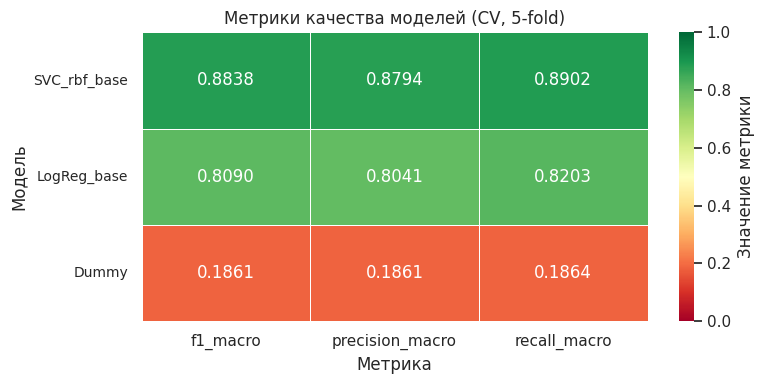

In [126]:
draw_metrics(baseline_df.sort_values('f1_macro', ascending=False))

✅ Обучены базовые модели (с гиперпараметрами по умолчанию). F1 выше требований уже даже без подбора гиперпараметров, но пока только на Train Set.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Подбор гиперпараметров моделей

In [127]:
# сетка для Логрег с lbfgs
grid_logreg = {
    'clf__solver': ['lbfgs'],
    "clf__C": [0.01, 0.1, 1, 10],
} #4 x 5 = 20 итераций

# сетка для Логрег с saga
grid_logreg_l1 = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['saga'],
    'clf__penalty': ['l1', 'l2']
} #8 x 5 = 40 итераций

# сетка SVC с нелинейными ядрами
grid_svc = [
    {"clf__kernel": ["linear"], "clf__C": [0.1, 1, 10]},
    {"clf__kernel": ["rbf"],    "clf__C": [1, 10], "clf__gamma": ["scale", 0.01, 0.1]},
    {"clf__kernel": ["poly"],   "clf__C": [1, 10], "clf__degree": [2, 3], "clf__gamma": ["scale"]},
] #13 x 5 = 65 итераций

# 👉 уточнение сетки после применения сетки grid_svc
grid_svc_final = [
    {"clf__kernel": ["rbf"],
     "clf__C":     [0.1, 0.25, 0.5, 0.75], # расширяем вниз
     "clf__gamma": [0.08, 0.1, 0.12]}, # уточняем вокруг 0.1
]

with config_context(display="text"):

    pipe_logreg = make_pipeline(
        LogisticRegression(max_iter=2000, class_weight='balanced',
                           solver='lbfgs')
    )

    gs_logreg = GridSearchCV(pipe_logreg, grid_logreg, cv=cv,
                             scoring=scoring, refit="f1_macro",
                             n_jobs=-1, verbose=1)

    # ищем отдельно: так как L1-регуляризация не совместима с lbfgs
    gs_logreg_l1 = GridSearchCV(pipe_logreg, grid_logreg_l1, cv=cv,
                             scoring=scoring, refit="f1_macro",
                             n_jobs=-1, verbose=1)
    
    # --- обучение ---
    gs_logreg.fit(X_train, y_train)
    gs_logreg_l1.fit(X_train, y_train)

    # ---------- SVC с разными ядрами ----------
    pipe_svc = make_pipeline(
        SVC(class_weight="balanced", cache_size=700, random_state=SEED)
    )
    
    gs_svc = GridSearchCV(pipe_svc, grid_svc_final, cv=cv,
                          scoring=scoring, refit="f1_macro",
                          n_jobs=-1, verbose=1)

    # --- обучение ---    
    gs_svc.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt/conda/envs/review_env/lib/python3.11/site-packages/joblib/_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: 'NoneType' object is not iterable.
  warnings.warn(
/opt

### Сравнение метрик и выбор лучшей модели

In [128]:
def best_cv_metrics(gs, name):
    i = gs.best_index_
    return {
        "model": name,
        "f1_macro":        gs.cv_results_["mean_test_f1_macro"][i],
        "f1_macro_std":        gs.cv_results_["std_test_f1_macro"][i],
        "precision_macro": gs.cv_results_["mean_test_precision_macro"][i],
        "recall_macro":    gs.cv_results_["mean_test_recall_macro"][i],        
        "fit_time":    gs.cv_results_["mean_fit_time"][i],
        "best_params":     gs.best_params_,
    }

tuned_df = pd.DataFrame([
    best_cv_metrics(gs_logreg, "LogReg"),
    best_cv_metrics(gs_logreg_l1, "LogReg L1 saga"),
    best_cv_metrics(gs_svc,    "SVC"),
]).set_index("model")

combined_df = pd.concat([baseline_df, tuned_df], axis=0)

show_metrics(combined_df, '=== После подбора гиперпараметров на Train Set ===')

=== После подбора гиперпараметров на Train Set ===


,f1_macro,f1_macro_std,precision_macro,recall_macro,fit_time,best_params
model,,,,,,
SVC,0.8870,0.0078,0.8858,0.8892,1.26 s,"{'clf__C': 0.75, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}"
SVC_rbf_base,0.8838,0.0066,0.8794,0.8902,1.06 s,-
LogReg L1 saga,0.8103,0.0194,0.8051,0.8215,1.04 s,"{'clf__C': 1, 'clf__penalty': 'l1', 'clf__solver': 'saga'}"
LogReg_base,0.8090,0.0184,0.8041,0.8203,1.17 s,-
LogReg,0.8090,0.0184,0.8041,0.8203,1.05 s,"{'clf__C': 1, 'clf__solver': 'lbfgs'}"
Dummy,0.1861,0.0171,0.1861,0.1864,1.02 s,-


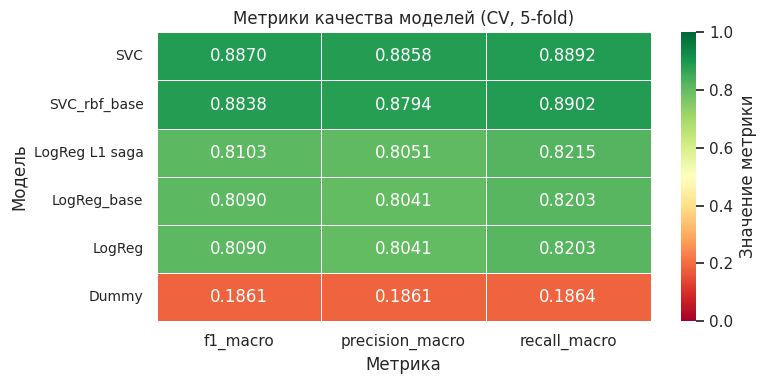

In [129]:
draw_metrics(combined_df.sort_values('f1_macro', ascending=False))

In [130]:
candidates = {
    "LogReg": gs_logreg,
    "LogReg_L1_saga": gs_logreg_l1,
    "SVC":    gs_svc,
}

best_name = max(candidates, key=lambda k: candidates[k].best_score_)
best_cv = candidates[best_name]
best_model = best_cv.best_estimator_

print(f'👉 Лучшая модель по F1-macro: {best_name} '
      f'({best_cv.best_score_:.4f}) '
      f'с параметрами: {best_cv.best_params_}'
     )

👉 Лучшая модель по F1-macro: SVC (0.8870) с параметрами: {'clf__C': 0.75, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Нужна табличка сравнения всех оценённых в проекте моделей для выбора Лучшей. </font>
> Выведите на экран в отсортированном табличном виде метрики на кросс-валидации для каждой изученной архитектуры модели, включая базовую.

<span style="color: purple; font-weight: bold">Комментарий студента it1</span>

Переделал отображение метрик и сделал общую таблицу моделей. Добавил тепловых карт для наглядности.


===== SVC — метрики на Test Set =====
F1-macro:        0.8774
Precision-macro: 0.8750
Recall-macro:    0.8809

               precision    recall  f1-score   support

  0: <18 лет       0.87      0.86      0.86       256
1: 18-25 лет       0.75      0.83      0.79       154
2: 26-40 лет       0.88      0.88      0.88       432
3: 41-55 лет       0.94      0.89      0.91       376
  4: 56+ лет       0.93      0.94      0.94       530

    accuracy                           0.89      1748
   macro avg       0.87      0.88      0.88      1748
weighted avg       0.90      0.89      0.89      1748



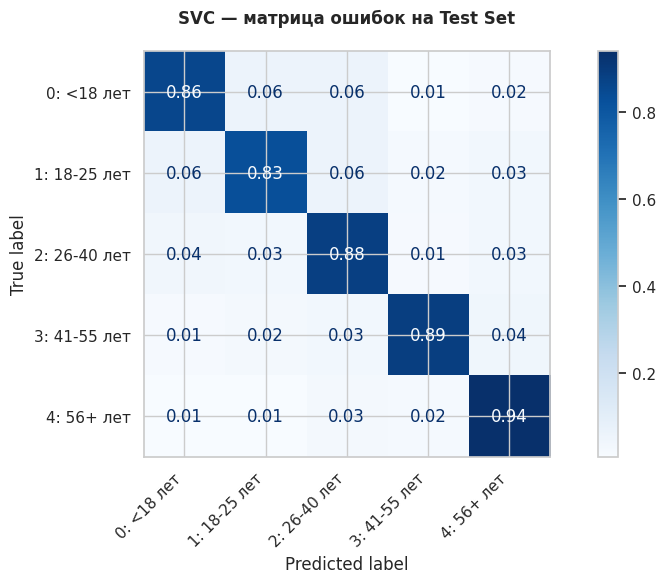

In [131]:
y_pred = best_model.predict(X_test)

print(f"\n===== {best_name} — метрики на Test Set =====")
print(f"F1-macro:        {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Precision-macro: {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall-macro:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print("\n", classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title(f"{best_name} — матрица ошибок на Test Set", pad = 20, weight='bold')
plt.tight_layout()
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

In [132]:
# проверка на переобучение победившей модели
cv_score = candidates[best_name].best_score_
test_score = f1_score(y_test, y_pred, average="macro")

print(f"\nCV  F1-macro (train): {cv_score:.4f}")
print(f"Test F1-macro:        {test_score:.4f}")
print(f"Разрыв:               {cv_score - test_score:+.4f}")
# большой положительный разрыв (>0.03-0.05) → переобучение / оптимистичный CV


CV  F1-macro (train): 0.8870
Test F1-macro:        0.8774
Разрыв:               +0.0096


### Важность признаков

In [133]:
prep = best_model.named_steps['prep']
clf = best_model.named_steps['clf']

X_test_trans = prep.transform(X_test)

imp = permutation_importance(
    clf, X_test_trans, y_test,
    n_repeats=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=SEED,
)

feat_names = prep.get_feature_names_out()
importance = pd.Series(imp.importances_mean, index=feat_names).sort_values(ascending=False)

=== Топ-15 признаков для SVC по permutation importance (F1_macro) ===


,importance
std__wcat_share_category_16,0.053700
std__dt_share_вечер,0.052800
std__wcat_share_category_03,0.050000
std__wcat_share_category_13,0.049800
std__wcat_share_category_08,0.046200
std__wcat_share_category_07,0.037100
std__dt_share_ночь,0.031600
std__wcat_share_category_20,0.030700
std__wcat_share_category_18,0.029800
std__wcat_share_category_17,0.027700


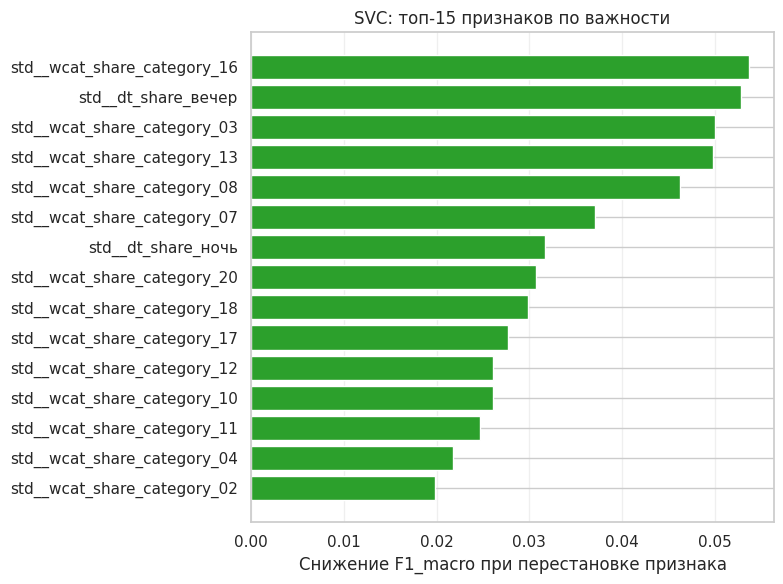

In [134]:
print(f"=== Топ-15 признаков для {best_name} по permutation importance (F1_macro) ===")

display(importance.head(15).to_frame('importance').round(4).
    style.set_table_attributes('style="max-height: none; overflow: visible;"'))

top = importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(range(len(top)), top.values, color='#2ca02c')
plt.yticks(range(len(top)), top.index)
plt.gca().invert_yaxis()
plt.xlabel('Снижение F1_macro при перестановке признака')
plt.title(f'{best_name}: топ-15 признаков по важности')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Промежуточный вывод

#### 1. Отбор признаков

Квази-константные признаки (проверка до кодирований пайплайном) не обнаружены.  
Встроенный метод `SelectFromModel` на основе случайного леса отобрал **20 наиболее значимых признаков** из 39 после кодирования.  
Остальные 19 признаков слабых исключены, что снижает размерность без потери качества.

#### 2. Обучение и выбор моделей

На кросс-валидации (5 фолдов) базовые модели показали на Train Set:  
- SVC с RBF-ядром – F1 macro ≈ **0.8838**  
- Логистическая регрессия – F1 ≈ **0.8090**  
- Dummy – F1 ≈ **0.1861**

После подбора гиперпараметров (`GridSearch`) лучший результат остался у **SVC ('C': 0.75, 'gamma': 0.1, 'kernel': 'rbf')** с F1 на кросс-валидации **0.8870**, Train Set.

Модель превзошла LogisticRegression, так как в датасете есть нелинейные немонотонные признаки, например, cloud_usage, ads_activity.

#### 3. Оценка на тестовой выборке

Финальная модель SVC показала на тесте:  
- F1 macro = **0.8774** (требование ≥ 0.75 выполнено с запасом)  
- Precision macro = **0.8750**  
- Recall macro = **0.8809**

Матрица ошибок демонстрирует хорошую различимость всех возрастных групп, особенно для классов 2–4 (26+ лет).  
Разрыв между CV и тестом составляет всего **+0.0096**, что свидетельствует об отсутствии переобучения и хорошей обобщающей способности. Precision и Recall хорошо сбалансированы не только в целом, но и по классам, что означает хороший охват и точность прогнозирования для каждой отдельной категории возраста.

Самый проблемный класс – 1 (18–25 лет): Precision (0.75) заметно ниже recall (0.83). Модель часто даёт ложноположительные срабатывания по этому классу.

Это может быть следствием малого размера выборки (всего 8.8%) и схожести поведенческих паттернов с соседними возрастными группами (особенно с классом 0 и 2).

  
#### Итог

- Создан воспроизводимый пайплайн предобработки с кодированием и отбором признаков.
- Создана функция предварительной подготовки данных:
`def merge_yeti_df(file_names: YetiDatasetFilesProto, loader: Callable[[str], pd.DataFrame]) -> pd.DataFrame`.
- Базовая модель SVC с подобранными гиперпараметрами обеспечивает стабильное качество, превышающее заданное пороговое значение на тестовых данных 0.75 --> 0.8779.  
- Решение готово к внедрению, модель обучена на полной Tarin Set ща счёт refit, и проверена на Test Set.

## Подготовка артефактов модели для внедрения

In [135]:
MODEL_FILE_NAME = 'yeti_svc_rbf_model.dill'
PREPROC_FILE = 'preprocessing_deps.dill'

# pre_transformer merge_yeti_df и его зависимости
preprocessing_deps = {
    'merge_yeti_df': merge_yeti_df,
    'normalize_text_cols': normalize_text_cols,
    'downcast_columns_for_ml': downcast_columns_for_ml,
    'dedup_full_rows': dedup_full_rows,
    'drop_columns_inplace_safe': drop_columns_inplace_safe,
    'TARGET': TARGET,
}

model_descriptor = {
    # весь пайплайн: препроцессинг + отбор признаков + SVC
    'pipeline': best_model,

    'metrics': {
        'cv': {
            'f1_macro': float(cv_score), # = candidates[best_name].best_score_
        },
        'test': {
            'f1_macro':        float(test_score), 
            'precision_macro': float(precision_score(y_test, y_pred,
                                                     average='macro', zero_division=0)),
            'recall_macro':    float(recall_score(y_test, y_pred, average='macro')),
        },
        'cv_test_gap': float(cv_score - test_score),
    },

    'meta': {
        'model_name':        best_name,
        'best_params':       candidates[best_name].best_params_,
        'target':            TARGET,
        'classes':           best_model.classes_.tolist(),
        'raw_input_columns': list(X_train.columns),
        'n_raw_features':    X_train.shape[1],
        'features_dropped_by_selection': list(FEATURES_TO_DROP),
        'requires_pretransform': 'merge_yeti_df() before predict',
        'trained_at':        datetime.now().isoformat(timespec='seconds'),
        'sklearn_version':   sklearn.__version__,
        'seed':              SEED,
        'preprocessing_deps_file': PREPROC_FILE,
        'merge_yeti_df_code': inspect.getsource(merge_yeti_df) # это для справки и для доступа к коду
    },
}

with open(PREPROC_FILE, 'wb') as f:
    dill.dump(preprocessing_deps, f)

with open(MODEL_FILE_NAME, 'wb') as f:
    dill.dump(model_descriptor, f, protocol=4)
    
print('✅ Модель сохранена:', [MODEL_FILE_NAME] + [PREPROC_FILE])

✅ Модель сохранена: ['yeti_svc_rbf_model.dill', 'preprocessing_deps.dill']


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red"> С моделью нужно сохранить всю предобработку: merge_yeti_df, YetiDatasetFiles, load_df)</span>
> Иными словами, если вы используете перед пайплайном с моделью отдельную функцию для объединения датафреймов и создания признаков, то не забудьте сохранить в отдельный файл и эту функцию. Без неё внедрение модели в эксплуатацию будет невозможно.

<span style="color: purple; font-weight: bold">Комментарий студента it1</span>

Добавил сохранение через dill, но это дурно пахнет. Нужно делать нормальный проект с модулями и выкладывать в GitHub.

Для справки, ещё и сам код надо запихивать в мету. Я его записал без зависимостей.

Ну, или не функцию делать, а класс, в котором всё есть. Его записать легче.

### Проверка сохранённой модели

In [136]:
with open(MODEL_FILE_NAME, 'rb') as f:
    descriptor = dill.load(f)

PREPROC_FILE = descriptor['meta']['preprocessing_deps_file']
with open(PREPROC_FILE, 'rb') as f:
    deps = dill.load(f)
    
merge_yeti_df_loaded = deps['merge_yeti_df'] # зависимости грузить не будем, в Notebook они есть и так

loaded_model = descriptor['pipeline']
metrics = descriptor['metrics']
model_name = descriptor['meta']['model_name']

row = {
    'model_name':      model_name,
    'cv_f1_macro':     metrics['cv']['f1_macro'],
    'test_f1_macro':   metrics['test']['f1_macro'],
    'test_precision':  metrics['test']['precision_macro'],
    'test_recall':     metrics['test']['recall_macro'],
    'cv_test_gap':     metrics['cv_test_gap'],
}

metrics_df = pd.DataFrame([row])

display(metrics_df)

,model_name,cv_f1_macro,test_f1_macro,test_precision,test_recall,cv_test_gap
0,SVC,0.887035,0.87739,0.874961,0.880922,0.009645


In [137]:
print('Метаданные модели:\n')
pprint(descriptor['meta'])

Метаданные модели:

{'best_params': {'clf__C': 0.75, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'},
 'classes': ['0: <18 лет',
             '1: 18-25 лет',
             '2: 26-40 лет',
             '3: 41-55 лет',
             '4: 56+ лет'],
 'features_dropped_by_selection': ['std__wcat_share_category_19',
                                   'std__wcat_share_category_06',
                                   'std__wcat_entropy',
                                   'logrob__visits_per_day',
                                   'std__weekend_share',
                                   'ohe_cloud__cloud_usage_1',
                                   'ohe_cat__primary_device_смартфон',
                                   'ohe_cat__ads_activity_очень редко',
                                   'ohe_cat__ads_activity_часто',
                                   'ohe_cat__ads_activity_умеренно',
                                   'ohe_cat__ads_activity_редко',
                                   'ohe_cat__surf_

In [138]:
# загружаем и склеиваем сырые данные, проверяем merge_yeti_df_loaded
df_result = merge_yeti_df_loaded(YetiDatasetFiles(), load_df)

# для теста берём 10 случайных строк
df_sample = df_result.sample(n=10, random_state=SEED)

y_true = df_sample['age_category']
X_sample = df_sample.drop(columns=['age_category'])

# предсказания модели 
predictions = loaded_model.predict(X_sample)

# вероятности (если модель их поддерживает) 
has_proba = hasattr(loaded_model, "predict_proba")
if has_proba:
    proba = loaded_model.predict_proba(X_sample)          # shape (10, 5)
    classes = loaded_model.classes_
    proba_pred = proba.max(axis=1).round(3)               # уверенность в предсказании
else:
    proba = None
    proba_pred = [None] * len(predictions)

✅ Датасет загружен с "/datasets/ds_s13_users.csv" содержит: 5913 строк
✅ Датасет ds_s13_users.csv очищен от дубликатов: 5913 --> 5826 / удалено: 87 
✅ Датасет загружен с "/datasets/ads_activity.csv" содержит: 5826 строк
✅ Датасет ads_activity.csv очищен от дубликатов: 5826 --> 5593 / удалено: 233 
✅ Датасет загружен с "/datasets/surf_depth.csv" содержит: 5715 строк
✅ Датасет загружен с "/datasets/primary_device.csv" содержит: 5669 строк
✅ Датасет загружен с "/datasets/cloud_usage.csv" содержит: 5680 строк
✅ Датасет загружен с "/datasets/ds_s13_visits.csv" содержит: 1065745 строк
✅ Датасет ds_s13_visits.csv очищен от дубликатов: 1065745 --> 1049995 / удалено: 15750 


In [139]:
result_df = pd.DataFrame({
    'index':          y_true.index,
    'Предсказание':   list(predictions),
    'Истинный класс': y_true.to_list(),
    'Уверенность':    list(proba_pred),
}).reset_index(drop=True)

result_df['Верно'] = result_df['Предсказание'] == result_df['Истинный класс']

def highlight_mismatch(row):
    color = '#ffdddd' if not row['Верно'] else '#ddffdd'
    return [f'background-color: {color}'] * len(row)

def fmt_proba(x):
    return f'{x:.3f}' if x is not None else '—'

display(result_df.style.apply(highlight_mismatch, axis=1)
        .format({'Уверенность': fmt_proba}))

acc = result_df['Верно'].mean()
print(f"Точность на демонстрационной выборке: {acc:.2%} "
      f"({result_df['Верно'].sum()}/{len(result_df)})")

,index,Предсказание,Истинный класс,Уверенность,Верно
0,4071,4: 56+ лет,4: 56+ лет,—,True
1,4880,0: <18 лет,0: <18 лет,—,True
2,1121,3: 41-55 лет,3: 41-55 лет,—,True
3,561,2: 26-40 лет,2: 26-40 лет,—,True
4,1188,2: 26-40 лет,2: 26-40 лет,—,True
5,3441,4: 56+ лет,4: 56+ лет,—,True
6,5589,2: 26-40 лет,2: 26-40 лет,—,True
7,4928,0: <18 лет,1: 18-25 лет,—,False
8,3944,2: 26-40 лет,0: <18 лет,—,False
9,3909,3: 41-55 лет,3: 41-55 лет,—,True


Точность на демонстрационной выборке: 80.00% (8/10)


## Выводы о результатах работы

Разработан классификатор для прогнозирования возрастной категории пользователей (5 классов) на основе веб-логов.  
Итоговое качество на тестовой выборке:  
- **F1 macro = 0.877** (требование ≥ 0.75 перекрыто с большим запасом)  
- **Precision macro = 0.875**, **Recall macro = 0.881** – метрики сбалансированы.

**Решение**

Создан хэлпер (`merge_yeti_df`), который из шести сырых таблиц строит компактный датасет (29 признаков) с агрегированными поведенческими характеристиками.  
Встроенная предобработка включает:
- нормализацию и оптимизацию типов;
- удаление дубликатов;
- заполнение пропусков в category-признаках при помощи категории unknown;
- создание производных признаков (доли посещений по времени суток, категориям сайтов, энтропия, плотность активности).

**Отбор признаков и моделирование**

После OHE и масштабирования (39 признаков) `SelectFromModel` на основе `RandomForest` отобрал **20 наиболее информативных** признаков (удалены 19 слабых).  
Лучшая модель – **SVC с RBF-ядром** (`C = 0.75`, `gamma = 0.1`) – превзошла логистическую регрессию благодаря нелинейным зависимостям в данных.  
Гиперпараметры подобраны через `GridSearch`; дальнейшее уточнение не дало значимого прироста – мы упёрлись в информационный потолок данных.

**Стабильность и обобщаемость**

Разрыв между кросс-валидацией (0.887) и тестом (0.877) составляет **+0.010** – переобучение отсутствует, модель надёжна.  
Матрица ошибок показывает хорошую разделимость для классов 2–4 (26+ лет);  
класс 0 (до 18) и 1 (18–25) предсказываются хуже, особенно класс 1 (precision 0.75, recall 0.83) – это зона для улучшения за счёт сбора большего количества примеров или применения методов борьбы с дисбалансом.

**Готовность к внедрению**

Модель сериализована (`yeti_svc_rbf_model.joblib`) вместе с метаданными, пайплайн автономен.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

## Финальная очистка

In [140]:
memory.clear(warn=False)
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.


<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Алексей, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>